In [221]:
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Limpieza y Procesamiento de Datos

## Ejercicio 1

In [222]:
df_jugadores = pd.read_csv("jugadores.csv") # Cargamos jugadores.csv en un DataFrame
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_performance_cspct,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,22.6,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,21.9,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back


## Ejercicio 2

### a)

In [223]:
df_jugadores["seleccion"].nunique() # Cuántas selecciones distintas hay

48

In [224]:
selecciones = df_jugadores.groupby("seleccion")
selecciones.size().unique() # Cuántos jugadores hay por selección

array([26, 25])

In [225]:
selecciones.size()[selecciones.size() == 25]

seleccion
Austria    25
Canada     25
Jordan     25
dtype: int64

Todas las selecciones tienen 26 jugadores, excepto Austria, Canadá y Jordania que tienen 25

### b)

In [226]:
cantidad_jugadores_clubes = df_jugadores.groupby("club").size()
cantidad_jugadores_clubes[cantidad_jugadores_clubes>=10].sort_values()

club
Fenerbahçe             10
Milan                  10
Real Madrid            10
PSV Eindhoven          10
Slavia Prague          10
Galatasaray            11
Liverpool              11
Borussia Dortmund      11
Atlético Madrid        12
Manchester United      12
Crystal Palace         12
Al-Hilal               12
Barcelona              15
Paris Saint-Germain    16
Arsenal                16
Bayern Munich          18
Manchester City        19
dtype: int64

### c)

In [227]:
rango_etario = lambda edad : "A" if edad < 24 else ("B" if edad <= 30 else "C")
df_jugadores["rango_etario"] = [rango_etario(edad) for edad in df_jugadores["edad"]]
df_jugadores

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,keeper_penalty_kicks_pkatt,keeper_penalty_kicks_pka,keeper_penalty_kicks_pksv,keeper_penalty_kicks_pkm,keeper_penalty_kicks_savepct,keeper_playing_time_90s,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,4.0,3.0,0.0,1.0,0.0,31.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,NaN,NaN,NaN,NaN,NaN,NaN,CZE,7000000.0,Right-Back,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,6.0,2.0,2.0,2.0,50.0,32.0,PAN,350000.0,Goalkeeper,C
1241,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,7000000.0,Right-Back,B
1242,1243,Panama,24,FW,Azarias Londoño,2001-06-21,24,10,0,Universidad Católica,...,NaN,NaN,NaN,NaN,NaN,NaN,PAN,175000.0,Centre-Forward,B
1243,1244,Panama,25,DF,Roderick Miller,1992-04-03,34,50,2,Turan Tovuz,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175000.0,Centre-Back,C


In [228]:
top_cinco_ranking_fifa = ["Argentina", "Francia", "España", "Inglaterra", "Brasil"]
df_top_cinco = df_jugadores[df_jugadores["seleccion"].isin(top_cinco_ranking_fifa)]
df_top_cinco.groupby("rango_etario").size().sort_values(ascending=False)

rango_etario
B    15
C     8
A     3
dtype: int64

El rango etario dominante en las primeras cinco selecciones del ranking FIFA es entre 24 y 30 años

## Ejercicio 3

In [229]:
variables = ["standard_playing_time_mp", "shooting_90s", "misc_performance_fls", "playing_time_starts_starts"]
df_variables = df_jugadores[variables]
df_variables.notna().sum()/len(df_jugadores) * 100

standard_playing_time_mp      73.975904
shooting_90s                  74.056225
misc_performance_fls          71.405622
playing_time_starts_starts    38.232932
dtype: float64

Eliminamos todas las variables del grupo playing_time_, ya que no abarcan el 60% de cobertura

In [230]:
variables_playing_time = [col for col in df_jugadores.columns if col.startswith("playing_time_")]
df_jugadores.drop(columns=variables_playing_time, inplace=True)
df_jugadores.columns.size

82

## Ejercicio 4

Las variables que estén en NAN las podemos poner en 0, ya que se basan en tiros y si el jugador no realizó ninguno cualquier ratio debería dar 0

In [231]:
variables_shooting = [col for col in df_jugadores.columns if col.startswith("shooting_")]
df_jugadores.fillna({col : 0 for col in variables_shooting}, inplace=True) # Reemplazamos los valores faltantes por 0
print(df_jugadores[variables_shooting].isna().sum()) # Verificamos que los valores faltantes hayan sido reemplazados

shooting_90s                    0
shooting_standard_gls           0
shooting_standard_sh            0
shooting_standard_sot           0
shooting_standard_sotpct        0
shooting_standard_sh_per_90     0
shooting_standard_sot_per_90    0
shooting_standard_g_per_sh      0
shooting_standard_g_per_sot     0
shooting_standard_pk            0
shooting_standard_pkatt         0
dtype: int64


## Ejercicio 5

La baja cobertura de las variables keeper_ se debe a que solo aplica a aquellos jugadores que ocupen esta posición. Esto se puede arreglar reemplazando los NA por 0 excepto aquellos donde exista alguna variable similar en otro grupo (como partidos como titular o minutos jugados).

In [232]:
copia = df_jugadores.copy() # Hago una copia del DataFrame para no modificar el original
variables_keeper = [col for col in copia.columns if col.startswith("keeper_")]
copia.fillna({col: 0 for col in variables_keeper}, inplace=True) # Reemplazar los valores faltantes por 0
print(copia[variables_keeper].isna().sum()) # Verificar que los valores faltantes hayan sido reemplazados

keeper_playing_time_mp          0
keeper_playing_time_starts      0
keeper_playing_time_min         0
keeper_90s                      0
keeper_performance_ga           0
keeper_performance_ga90         0
keeper_performance_sota         0
keeper_performance_saves        0
keeper_performance_savepct      0
keeper_performance_w            0
keeper_performance_d            0
keeper_performance_l            0
keeper_performance_cs           0
keeper_performance_cspct        0
keeper_penalty_kicks_pkatt      0
keeper_penalty_kicks_pka        0
keeper_penalty_kicks_pksv       0
keeper_penalty_kicks_pkm        0
keeper_penalty_kicks_savepct    0
keeper_playing_time_90s         0
dtype: int64


## Ejercicio 6

In [233]:
porcentajes = (df_jugadores.notna().sum() / len(df_jugadores) * 100).sort_values() # Porcentaje de valores no faltantes por variable
porcentajes[porcentajes < 60] # Variables con menos del 60% de valores no faltantes

misc_performance_pkwon          0.000000
misc_performance_pkcon          0.000000
keeper_90s                      2.811245
keeper_playing_time_90s         4.417671
keeper_penalty_kicks_savepct    6.184739
keeper_performance_savepct      6.666667
keeper_performance_sota         6.746988
keeper_performance_saves        6.746988
keeper_performance_cspct        7.148594
keeper_performance_w            7.228916
keeper_performance_d            7.228916
keeper_playing_time_mp          7.228916
keeper_performance_ga           7.228916
keeper_playing_time_starts      7.228916
keeper_playing_time_min         7.228916
keeper_performance_ga90         7.228916
keeper_penalty_kicks_pka        7.228916
keeper_penalty_kicks_pkatt      7.228916
keeper_penalty_kicks_pksv       7.228916
keeper_penalty_kicks_pkm        7.228916
keeper_performance_l            7.228916
keeper_performance_cs           7.228916
dtype: float64

In [234]:
# Eliminamos las variables misc_performance_pkwon, misc_performance_pkcon, y las de keeper_ ya que tienen < 60% de cobertura.
df_jugadores_limpia = df_jugadores.drop(columns=["misc_performance_pkwon", "misc_performance_pkcon"] + variables_keeper)
df_jugadores_limpia.reset_index(drop=True, inplace=True) # Reiniciamos el índice del DataFrame
df_jugadores_limpia.columns.size

60

In [235]:
nulos_por_fila = df_jugadores_limpia.isna().sum(axis=1) # Cantidad de valores faltantes por fila
filas_con_nulos = nulos_por_fila.value_counts().sort_index() # Cantidad de filas con cierta cantidad de valores faltantes
pd.DataFrame({"cantidad_faltantes": filas_con_nulos.index, "cantidad_filas": filas_con_nulos.values})

,cantidad_faltantes,cantidad_filas
0,0,873
1,1,8
2,2,7
3,6,33
4,19,1
5,30,1
6,32,294
7,33,4
8,34,24


In [236]:
df_jugadores_limpia.drop(df_jugadores_limpia[nulos_por_fila>30].index, inplace=True) # Eliminamos filas con más de 30 valores faltantes (mas de la mitad de las variables)
df_jugadores_limpia.reset_index(drop=True, inplace=True) # Reseteamos el índice del DataFrame
df_jugadores_limpia

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,nat3,valor_mercado_eur,posicion_tm,rango_etario
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,5.0,0.0,0.0,1.0,0.0,0.0,CZE,7000000.0,Goalkeeper,B
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,22.0,0.0,4.0,40.0,17.0,0.0,CZE,4500000.0,Centre-Back,B
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,28.0,1.0,22.0,44.0,24.0,0.0,CZE,2200000.0,Centre-Back,C
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,10.0,0.0,6.0,20.0,15.0,0.0,CZE,5500000.0,Centre-Back,B
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,42.0,1.0,209.0,39.0,35.0,0.0,CZE,7000000.0,Right-Back,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
918,1239,Panama,20,MF,Aníbal Godoy,1990-02-10,36,159,4,San Diego FC,...,37.0,0.0,3.0,16.0,14.0,0.0,PAN,200000.0,Defensive Midfield,C
919,1240,Panama,21,MF,César Yanis,1996-01-28,30,56,5,Cobresal,...,36.0,4.0,39.0,24.0,13.0,0.0,PAN,250000.0,Right Winger,B
920,1241,Panama,22,GK,Orlando Mosquera,1994-12-25,31,47,0,Al-Fayha,...,8.0,0.0,0.0,0.0,0.0,1.0,PAN,350000.0,Goalkeeper,C
921,1242,Panama,23,DF,Michael Amir Murillo,1996-02-11,30,93,9,Beşiktaş,...,14.0,2.0,29.0,6.0,8.0,0.0,PAN,7000000.0,Right-Back,B


In [237]:
df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

misc_performance_crdr              1
misc_performance_2crdy             1
misc_90s                           1
misc_performance_og                1
misc_performance_crdy              1
standard_playing_time_mp           2
standard_playing_time_min          2
standard_playing_time_starts       2
standard_performance_crdr          2
standard_performance_pk            2
standard_performance_pkatt         2
standard_playing_time_90s          2
standard_performance_ast           2
standard_performance_gls           2
standard_performance_gpa           2
standard_performance_g-pk          2
standard_performance_crdy          2
standard_per_90_minutes_gpa        2
standard_per_90_minutes_gls        2
standard_per_90_minutes_ast        2
standard_per_90_minutes_gpa-pk     2
standard_per_90_minutes_g-pk       2
nation_fbref                       3
nat3                               3
posicion_tm                        6
valor_mercado_eur                 14
misc_performance_fld              34
m

In [238]:
# Reemplazamos los NA en misc_ y standard_ por 0, pues son variables que miden cantidades o proporciones, y el NA puede ser interpretado como 0.
variables_misc_performance = [col for col in df_jugadores_limpia.columns if col.startswith("misc_")]
variables_standard = [col for col in df_jugadores_limpia.columns if col.startswith("standard_")]
df_jugadores_limpia.fillna({col: 0 for col in variables_misc_performance + variables_standard}, inplace=True)
df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

nation_fbref          3
nat3                  3
posicion_tm           6
valor_mercado_eur    14
dtype: int64

In [239]:
# Vemos en qué jugadores faltan los valores de nation_fbref, nat3 y posicion_tm
df_jugadores_limpia[df_jugadores_limpia[["nation_fbref", "nat3", "posicion_tm"]].isna().sum(axis=1)>0][["seleccion", "posicion", "cod_fifa", "nation_fbref", "nat3", "posicion_tm"]]

,seleccion,posicion,cod_fifa,nation_fbref,nat3,posicion_tm
73,South Korea,MF,KOR,KOR,KOR,NaN
86,South Korea,MF,KOR,NaN,NaN,Central Midfield
171,Brazil,FW,BRA,BRA,BRA,NaN
253,Paraguay,MF,PAR,PAR,PAR,NaN
504,Egypt,DF,EGY,NaN,NaN,Centre-Back
524,Iran,FW,IRN,NaN,NaN,Centre-Forward
572,Saudi Arabia,MF,KSA,KSA,KSA,NaN
737,Argentina,MF,ARG,ARG,ARG,NaN
771,Jordan,FW,JOR,JOR,JOR,NaN


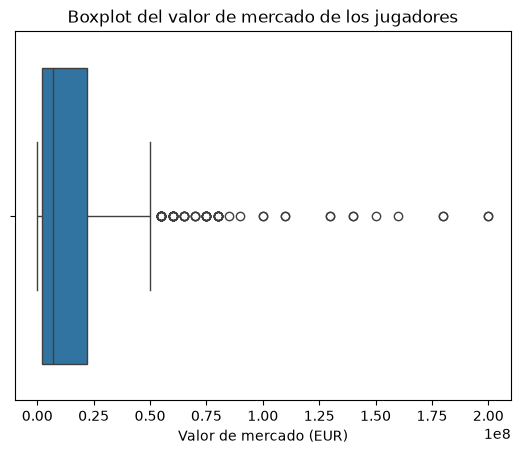

In [240]:
# Ahora realizamos el boxplot
(
	sns.boxplot(x = df_jugadores_limpia["valor_mercado_eur"])
	.set(xlabel='Valor de mercado (EUR)', title='Boxplot del valor de mercado de los jugadores')
)
plt.show()

In [241]:
# Rellenamos los valores faltantes copiando de otras variables
df_jugadores_limpia.fillna({col : df_jugadores_limpia["cod_fifa"] for col in ["nation_fbref", "nat3"]}, inplace=True)

# Reemplazamos en posicion_tm por central Midfield si posicion es MF, y sino por Centre-Forward
df_jugadores_limpia["posicion_tm"] = df_jugadores_limpia["posicion_tm"].fillna(df_jugadores_limpia.apply(lambda row: "Central Midfield" if row["posicion"] == "MF" else "Centre-Forward", axis=1))

# Reemplazamos los valores faltantes en valor_mercado_eur por el promedio de esta variable.
df_jugadores_limpia.fillna({"valor_mercado_eur" : df_jugadores_limpia["valor_mercado_eur"].mean()}, inplace=True)

df_jugadores_limpia.isna().sum()[df_jugadores_limpia.isna().sum()>0].sort_values() # Cantidad de valores faltantes por variable

Series([], dtype: int64)

In [242]:
print("Cantidad de jugadores: " + str(len(df_jugadores_limpia)))
print("Cantidad de variables numericas: " + str(len(df_jugadores_limpia.select_dtypes(include='number').columns)))

Cantidad de jugadores: 923
Cantidad de variables numericas: 45


## Ejercicio 7

In [243]:
selecciones_a_eliminar = df_jugadores_limpia["seleccion"].value_counts()[df_jugadores_limpia["seleccion"].value_counts()<=4].index
jugadores_a_eliminar = df_jugadores_limpia[df_jugadores_limpia["seleccion"].isin(selecciones_a_eliminar)].index
df_jugadores_limpia.drop(index=jugadores_a_eliminar, inplace=True) # Eliminamos los jugadores de las selecciones con 4 o menos jugadores
df_jugadores_limpia.reset_index(drop=True, inplace=True)

In [244]:
variables_numericas = df_jugadores_limpia.select_dtypes(include='number').drop(columns=["player_id", "numero"])
variables_numericas["seleccion"] = df_jugadores_limpia["seleccion"]
variables_numericas_seleccion_promedio = variables_numericas.groupby("seleccion").mean()
df_selecciones = variables_numericas_seleccion_promedio.reset_index()
df_selecciones.head()

,seleccion,edad,caps,goles_seleccion,standard_playing_time_mp,standard_playing_time_starts,standard_playing_time_min,standard_playing_time_90s,standard_performance_gls,standard_performance_ast,...,misc_performance_crdr,misc_performance_2crdy,misc_performance_fls,misc_performance_fld,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,valor_mercado_eur
0,Algeria,26.875000,41.375000,6.500000,24.937500,20.312500,1780.875000,19.768750,3.812500,3.062500,...,0.125000,0.000000,19.437500,20.687500,3.625000,54.312500,16.437500,17.750000,0.000000,1.072500e+07
1,Argentina,29.083333,50.541667,9.041667,24.375000,20.416667,1805.625000,20.070833,3.916667,2.833333,...,0.375000,0.083333,18.333333,25.166667,2.166667,33.875000,13.750000,16.916667,0.125000,3.032051e+07
2,Australia,26.850000,25.800000,2.100000,21.950000,18.150000,1637.150000,18.185000,1.100000,0.900000,...,0.050000,0.050000,15.100000,17.700000,1.150000,25.300000,14.100000,16.950000,0.000000,1.927500e+06
3,Austria,27.869565,37.260870,4.391304,25.478261,20.260870,1800.478261,20.000000,1.956522,2.000000,...,0.173913,0.043478,16.043478,17.739130,1.521739,22.565217,16.130435,18.695652,0.043478,1.199130e+07
4,Belgium,27.115385,41.000000,8.038462,28.192308,23.923077,2124.115385,23.596154,2.500000,2.615385,...,0.076923,0.038462,19.307692,22.653846,2.269231,35.500000,16.615385,19.230769,0.076923,1.982692e+07


# Análisis exploratorio

Se quiere analizar diferentes aspectos de las selecciones en función de su _tipo de juego_ (**ofensivo** o **defensivo**).

Para esto hay que definir cómo medir cuantitativamente la ofensiva y defensiva de un equipo: La idea es determinar las variables que describen la ofensiva y defensiva, luego escalarlas para estandarizar las medidas (que significan diferentes cosas y se miden en diferentes escalas y proporciones) y hacer un promedio ponderado de los puntajes estandarizados para crear un **indice de ofesiva** y un **indice de defensiva**.

Variables que describen un comportamiento OFENSIVO:
- **shooting_standard_sot_per_90**: Tiros al arco en un partido que llegan a generar presión sobre el arquero rival (si no ataja es gol). Medición de la peligrosidad de los ataques al arco.
- **shooting_standard_sh_per_90**: Tiros en un partido con intención de hacer gol pero que no generan presión sobre el arquero (sea porque un defensor bloquea el tiro, o porque se va afuera). Medición de volumen de ataques al arco. 
- **misc_performance_crs / misc_90s**: Medición de centros en un partido que indican juegos ofensivos por las bandas que llegan al área via centro.
- **misc_performance_fld / misc_90s**: Faltas recibidas en un partido que indican la presión que ejerce el equipo de manera que para frenarlos se llegan a cometer faltas.
- **misc_performance_off / misc_90s**: Faltas por _fuera de juego_ (offside) en un partido que indica un comportamiento de carrera a fondo del equipo para poder llegar al área rival.

Variables que describen un comportamiento DEFENSIVO:
- **misc_performance_int / misc_90s**: Intercepciones de la pelota en un partido para su recuperación.
- **misc_performance_tklw / misc_90s**: Entradas ganadas en un partido para la recuperación de la pelota.
- **misc_performance_fls / misc_90s**: Faltas cometidas en un partido como medición del último recurso para frenar la jugada de ataque.


In [245]:
# Creo un df con las variables que necesito a partir de df_selecciones
df_ofensiva_defensiva = df_selecciones[[
    "seleccion",
    "shooting_standard_sot_per_90",
    "shooting_standard_sh_per_90",
    "misc_90s",
    "misc_performance_crs",
    "misc_performance_fld",
    "misc_performance_off",
    "misc_performance_int",
    "misc_performance_tklw",
    "misc_performance_fls"]].set_index("seleccion")

# Proceso las variables de misc_performance para que sean por 90 minutos (por partido)
variables_misc = [col for col in df_ofensiva_defensiva.columns if col.startswith("misc_performance")]
df_ofensiva_defensiva[variables_misc] = df_ofensiva_defensiva[variables_misc].div(df_ofensiva_defensiva["misc_90s"], axis=0)
df_ofensiva_defensiva = df_ofensiva_defensiva.rename(columns={col: col + "_per_90" for col in variables_misc})
df_ofensiva_defensiva.drop(columns="misc_90s", inplace=True) # elimino del df la columna misc_90s que ya usé 

# Estandarizo las variables
df_ofensiva_defensiva = StandardScaler().set_output(transform="pandas").fit_transform(df_ofensiva_defensiva)

# Creo los indices de ofensiva y defensiva haciendo un promedio ponderado de las variables estandarizadas
df_ofensiva_defensiva["indice_ofensiva"] = 0.2 * df_ofensiva_defensiva["shooting_standard_sot_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["shooting_standard_sh_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_crs_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_fld_per_90"] +\
                                            0.2 * df_ofensiva_defensiva["misc_performance_off_per_90"]

df_ofensiva_defensiva["indice_defensiva"] = 0.34 * df_ofensiva_defensiva["misc_performance_int_per_90"] +\
                                            0.33 * df_ofensiva_defensiva["misc_performance_tklw_per_90"] +\
                                            0.33 * df_ofensiva_defensiva["misc_performance_fls_per_90"]


df_ofensiva_defensiva.head()

,shooting_standard_sot_per_90,shooting_standard_sh_per_90,misc_performance_crs_per_90,misc_performance_fld_per_90,misc_performance_off_per_90,misc_performance_int_per_90,misc_performance_tklw_per_90,misc_performance_fls_per_90,indice_ofensiva,indice_defensiva
seleccion,,,,,,,,,,
Algeria,0.467174,0.714620,1.754814,0.167699,0.483981,0.858111,0.435822,0.149741,0.717657,0.484993
Argentina,0.520614,0.325412,0.200991,0.960915,-0.729381,0.033712,0.156403,-0.168750,0.255710,0.007388
Australia,-0.686153,-0.646817,-0.233819,-0.112027,-1.448719,0.542098,0.609490,-0.547756,-0.625507,0.204685
Austria,-1.053853,-0.912987,-0.619475,-0.442339,-1.242017,0.717531,0.623176,-0.676320,-0.854134,0.226423
Belgium,0.002659,-0.056182,-0.067785,-0.162753,-0.918924,0.141159,0.014990,-0.602952,-0.240597,-0.146034


Con los indices de ofensiva y defensiva ya calculados por selección, ahora se suman otros datos para analizar en base a estos indices.

In [246]:
# Primero los datos de confederación a la cual pertenece cada selección, tomados de df_jugadores_limpia
df_ofensiva_defensiva["confederacion"] = df_jugadores_limpia.groupby("seleccion")["confederacion"].first()

# Ahora los datos de edad promedio, valor de mercado y la cantidad de mundiales promedio de cada jugador, tomados de df_selecciones
df_ofensiva_defensiva[["valor_mercado_eur", "edad", "caps"]] = df_selecciones.set_index("seleccion")[["valor_mercado_eur", 
                                                                                                        "edad", 
                                                                                                        "caps"]]

# Mejoro la visualización del valor de mercado para que sea mas legible
df_ofensiva_defensiva["valor_mercado_eur"] = df_ofensiva_defensiva["valor_mercado_eur"] / 1_000_000
df_ofensiva_defensiva = df_ofensiva_defensiva.rename(columns={"valor_mercado_eur": "valor_mercado_mill_eur"})

In [247]:
df_ofensiva_defensiva[["confederacion","edad","caps","indice_ofensiva","indice_defensiva","valor_mercado_mill_eur" ]].head()

,confederacion,edad,caps,indice_ofensiva,indice_defensiva,valor_mercado_mill_eur
seleccion,,,,,,
Algeria,CAF,26.875000,41.375000,0.717657,0.484993,10.725000
Argentina,CONMEBOL,29.083333,50.541667,0.255710,0.007388,30.320511
Australia,AFC,26.850000,25.800000,-0.625507,0.204685,1.927500
Austria,UEFA,27.869565,37.260870,-0.854134,0.226423,11.991304
Belgium,UEFA,27.115385,41.000000,-0.240597,-0.146034,19.826923


#### ¿Como es el estilo de juego de las selecciones según la confederación de futbol a la que pertenecen?

**Conclusiones:**

Si bien en la dispersión de selecciones se pueden identificar outliers, también se puede ver como la gran mayoria de las selecciones participantes del mundial 2026 tienen una eficacia en ataque y defensa cercanas al promedio (coordenada (0,0)). Si se hace un estudio por confederación se puede ver que:

- CONMEBOL: Sus selecciones destacan más por su defensa que por la ofensiva.
- UEFA: Al reves que con la CONMEBOL, las selecciones de esta federación son mas eficaces en ataque que en defensa, siendo la defensa en promedio peor que las defensas del resto de selecciones.
- CAF y AFC: Son las confederaciones que mayor diferencia presentan entre sus selecciones, pudiendose observar en el gráfico de dispersión una gran variedad de eficacias y deficiencias tanto en ataque como en defensa. Tienen selecciones con valores de indices muy extremos, por lo que los promedios de los indices pueden estár distorcionados.
- CONCAF: Las selecciones de esta confederación presentan una mejor eficacia en defensa que el promedio de todas las selecciones, pero no tan superior como lo es la defensa en las selecciones de la CONMEBOL. Por otro lado, no destácan en ataque, siendo su eficacia peor que el promedio.
- OFC: Se cuentan con datos de una única selección de esta confederación, por lo que no es representativo de todas las selecciones que hay en la misma. Lo que si se puede decir es que Nueva Zelanda presenta una muy buena eficacia en su defensa, sin embargo su ofensiva es peor que el promedio de todas las selecciones.

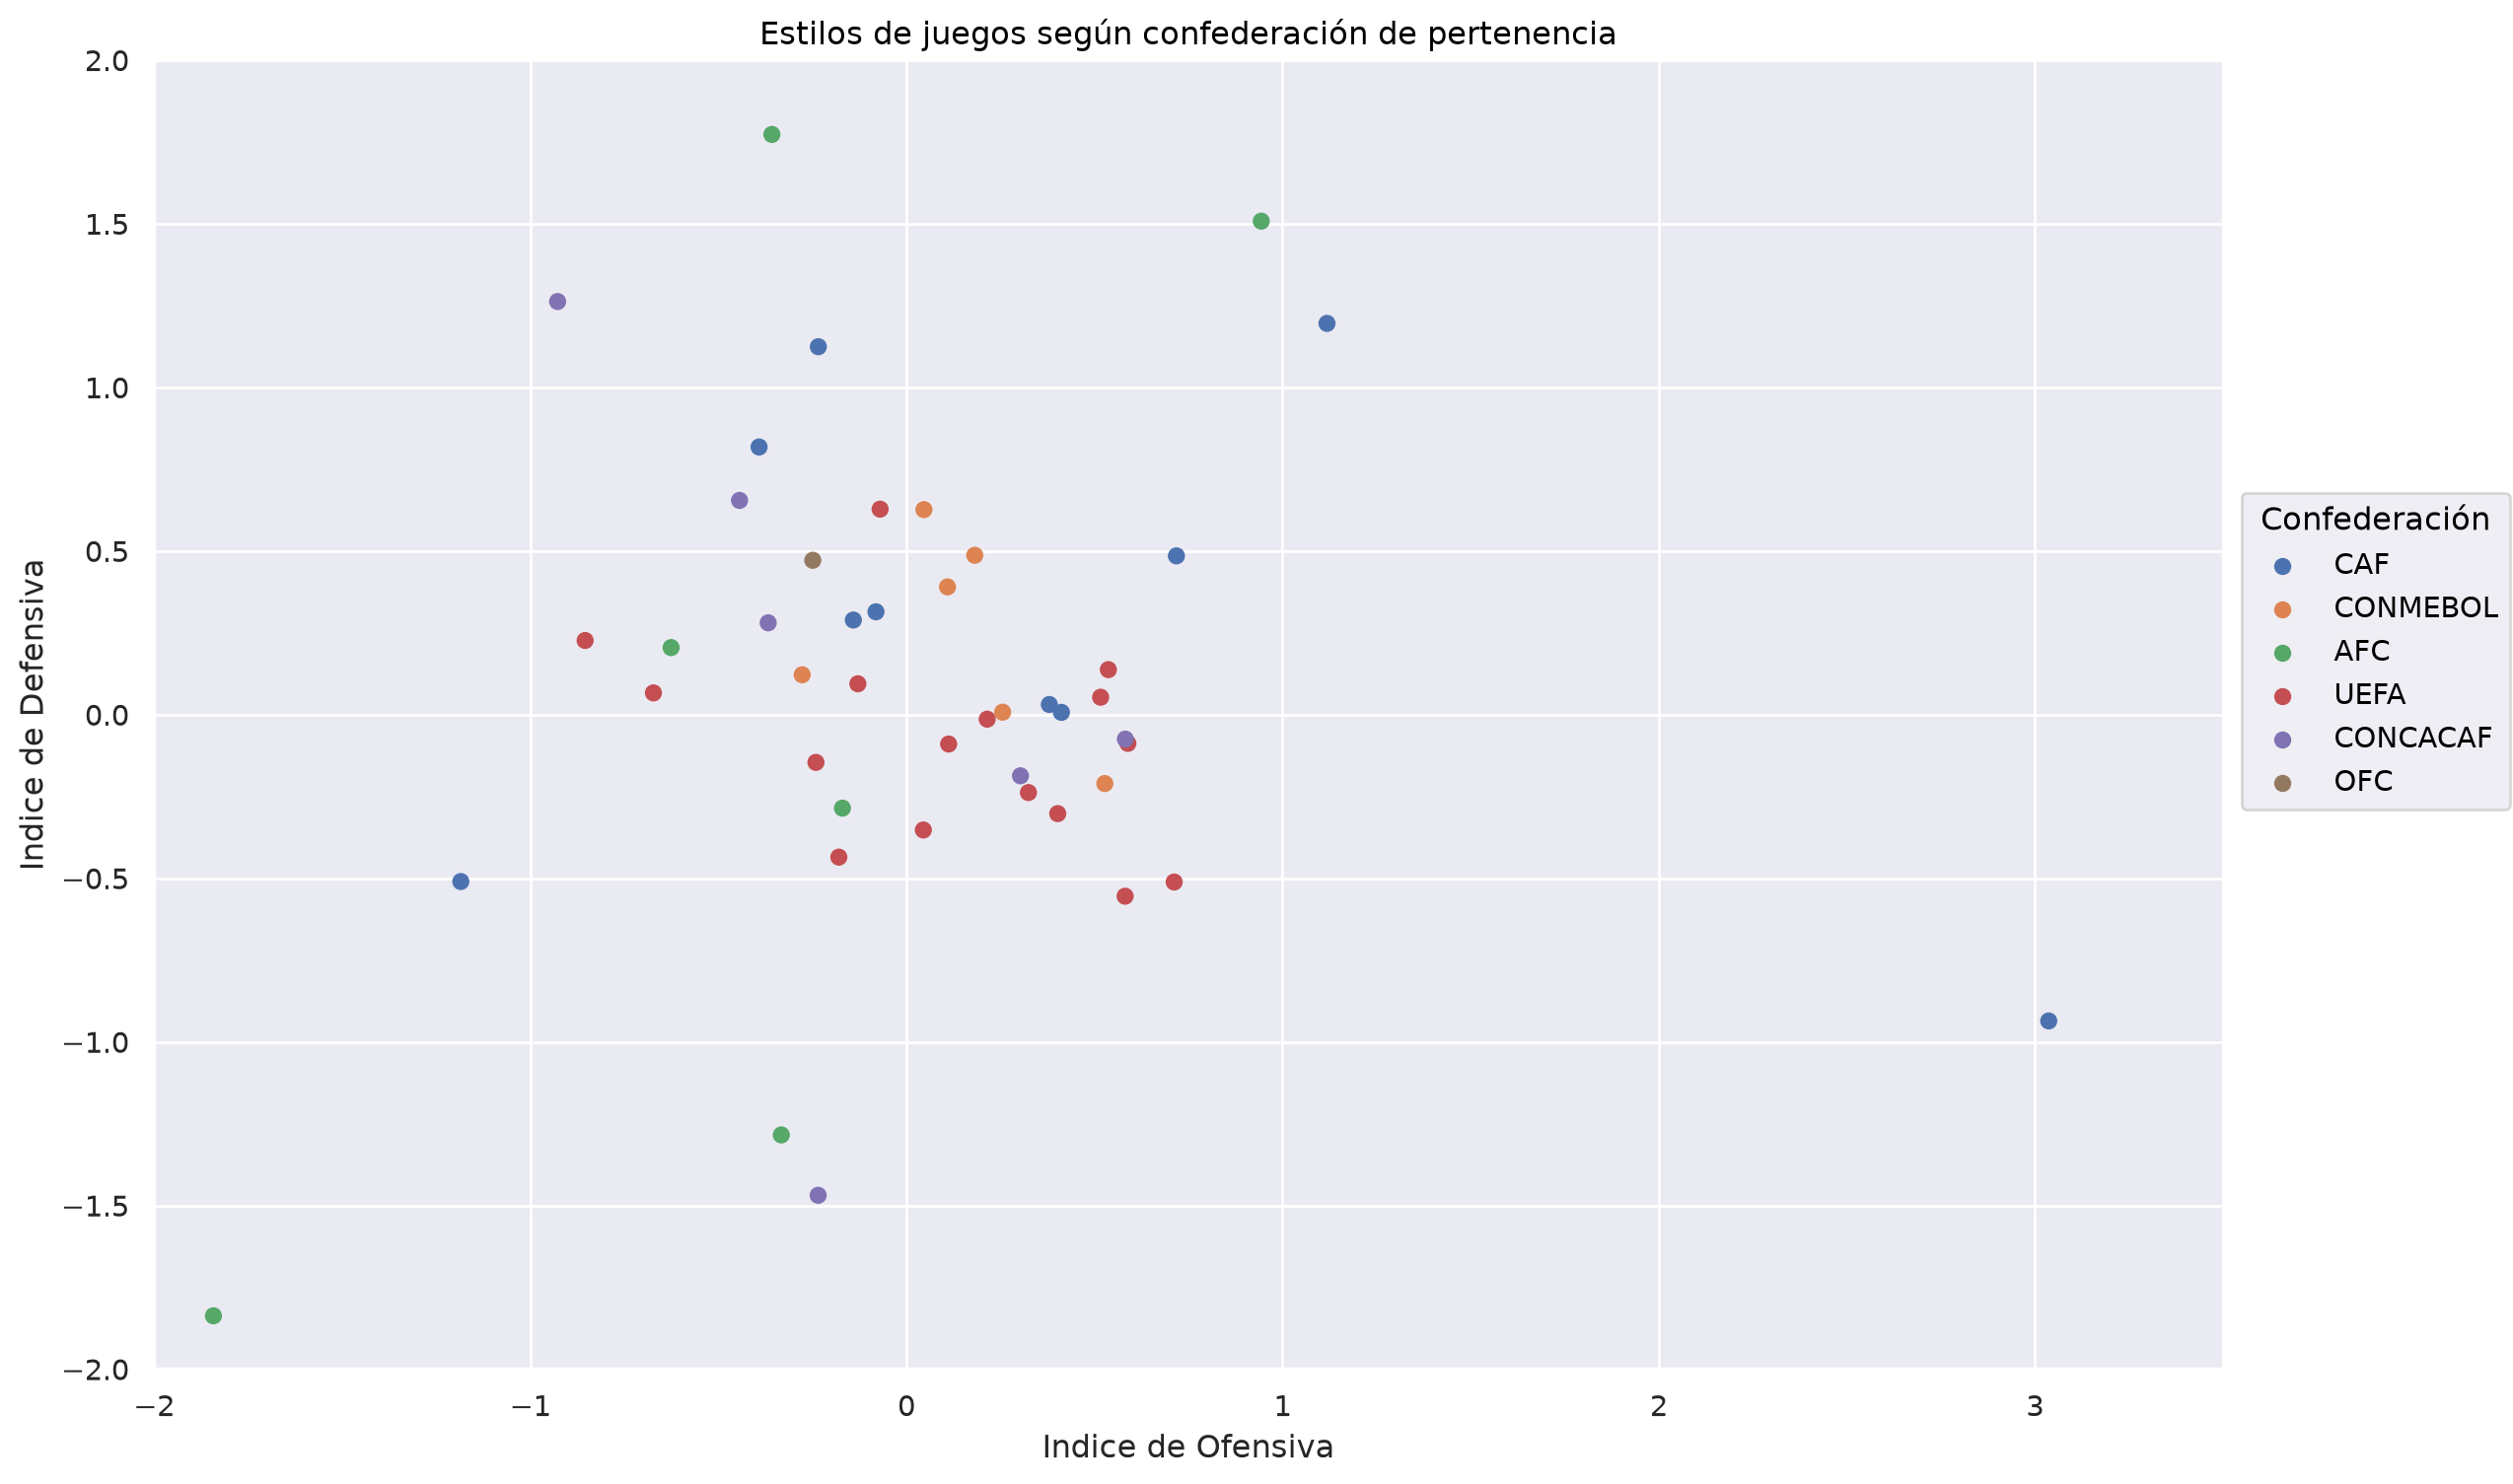

In [248]:
(
        so.Plot(data = df_ofensiva_defensiva,
                x = "indice_ofensiva",
                y = "indice_defensiva",
                color="confederacion",)
        .add(so.Dot())
        .limit(x=(-2, 3.5), y=(-2, 2))
        .layout(size=(12,8))
        .label(
                x="Indice de Ofensiva",
                y="Indice de Defensiva",
                title="Estilos de juegos según confederación de pertenencia",
                color="Confederación"
        )
)

In [249]:
# Promedios de indices según confederación y tamaño de la muestr (selecciones
df_confederaciones = (
    df_ofensiva_defensiva
    .groupby("confederacion")
    .agg(
        indice_ofensiva  = ("indice_ofensiva",  "mean"),
        indice_defensiva = ("indice_defensiva", "mean"),
        cant_selecciones    = ("indice_ofensiva",  "count")
    )
    .round(2)
)

df_confederaciones

,indice_ofensiva,indice_defensiva,cant_selecciones
confederacion,,,
AFC,-0.72,-0.52,7
CAF,0.36,0.28,10
CONCACAF,-0.18,0.08,6
CONMEBOL,0.14,0.24,6
OFC,-0.25,0.47,1
UEFA,0.12,-0.10,16


In [250]:
df_ofensiva_defensiva[df_ofensiva_defensiva["confederacion"] == "OFC"]

,shooting_standard_sot_per_90,shooting_standard_sh_per_90,misc_performance_crs_per_90,misc_performance_fld_per_90,misc_performance_off_per_90,misc_performance_int_per_90,misc_performance_tklw_per_90,misc_performance_fls_per_90,indice_ofensiva,indice_defensiva,confederacion,valor_mercado_mill_eur,edad,caps
seleccion,,,,,,,,,,,,,,
New Zealand,0.068805,-0.085047,0.470181,-0.591497,-1.107142,1.298378,0.67718,-0.586043,-0.24894,0.471524,OFC,0.910937,28.6875,31.5625


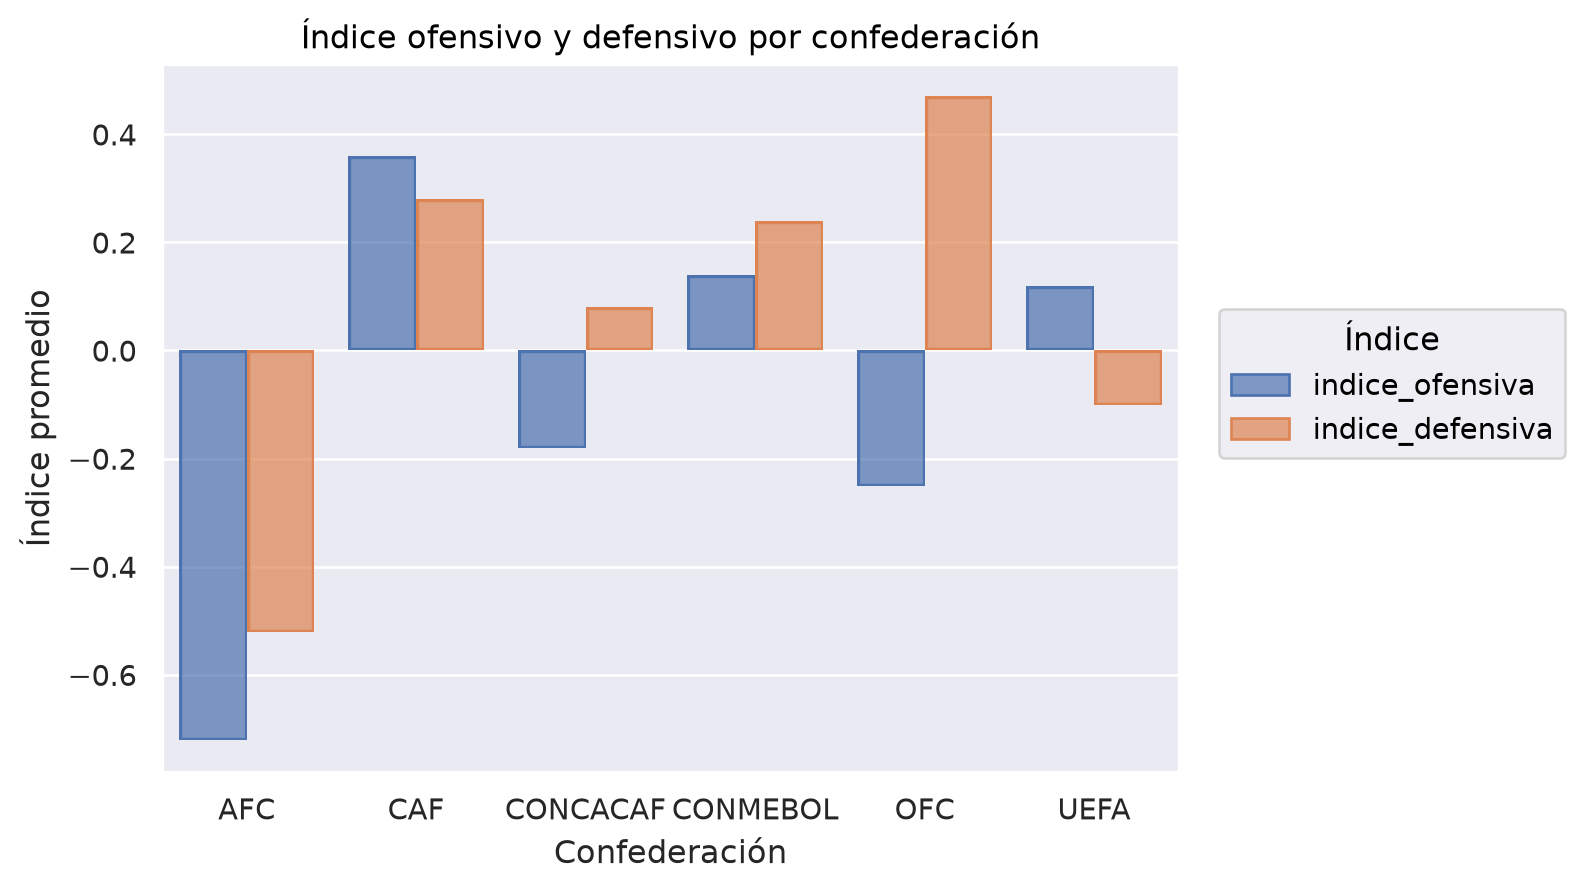

In [251]:
df_confederaciones_plot = df_confederaciones.reset_index().melt(
    id_vars="confederacion",
    value_vars=["indice_ofensiva", "indice_defensiva"],
    var_name="indice",
    value_name="valor"
)

(
    so.Plot(data=df_confederaciones_plot, x="confederacion", y="valor", color="indice")
    .add(so.Bar(), so.Dodge())
    .label(
        x="Confederación",
        y="Índice promedio",
        title="Índice ofensivo y defensivo por confederación",
        color="Índice"
    )
)

# PCA y Clustering

## Ejercicio 1

In [252]:
# Nos quedamos con las variables numéricas y las escalamos
df_selecciones_numerica = df_selecciones.drop(columns=["seleccion"])
df_selecciones_numerica_escalada = StandardScaler().set_output(transform="pandas").fit_transform(df_selecciones_numerica)

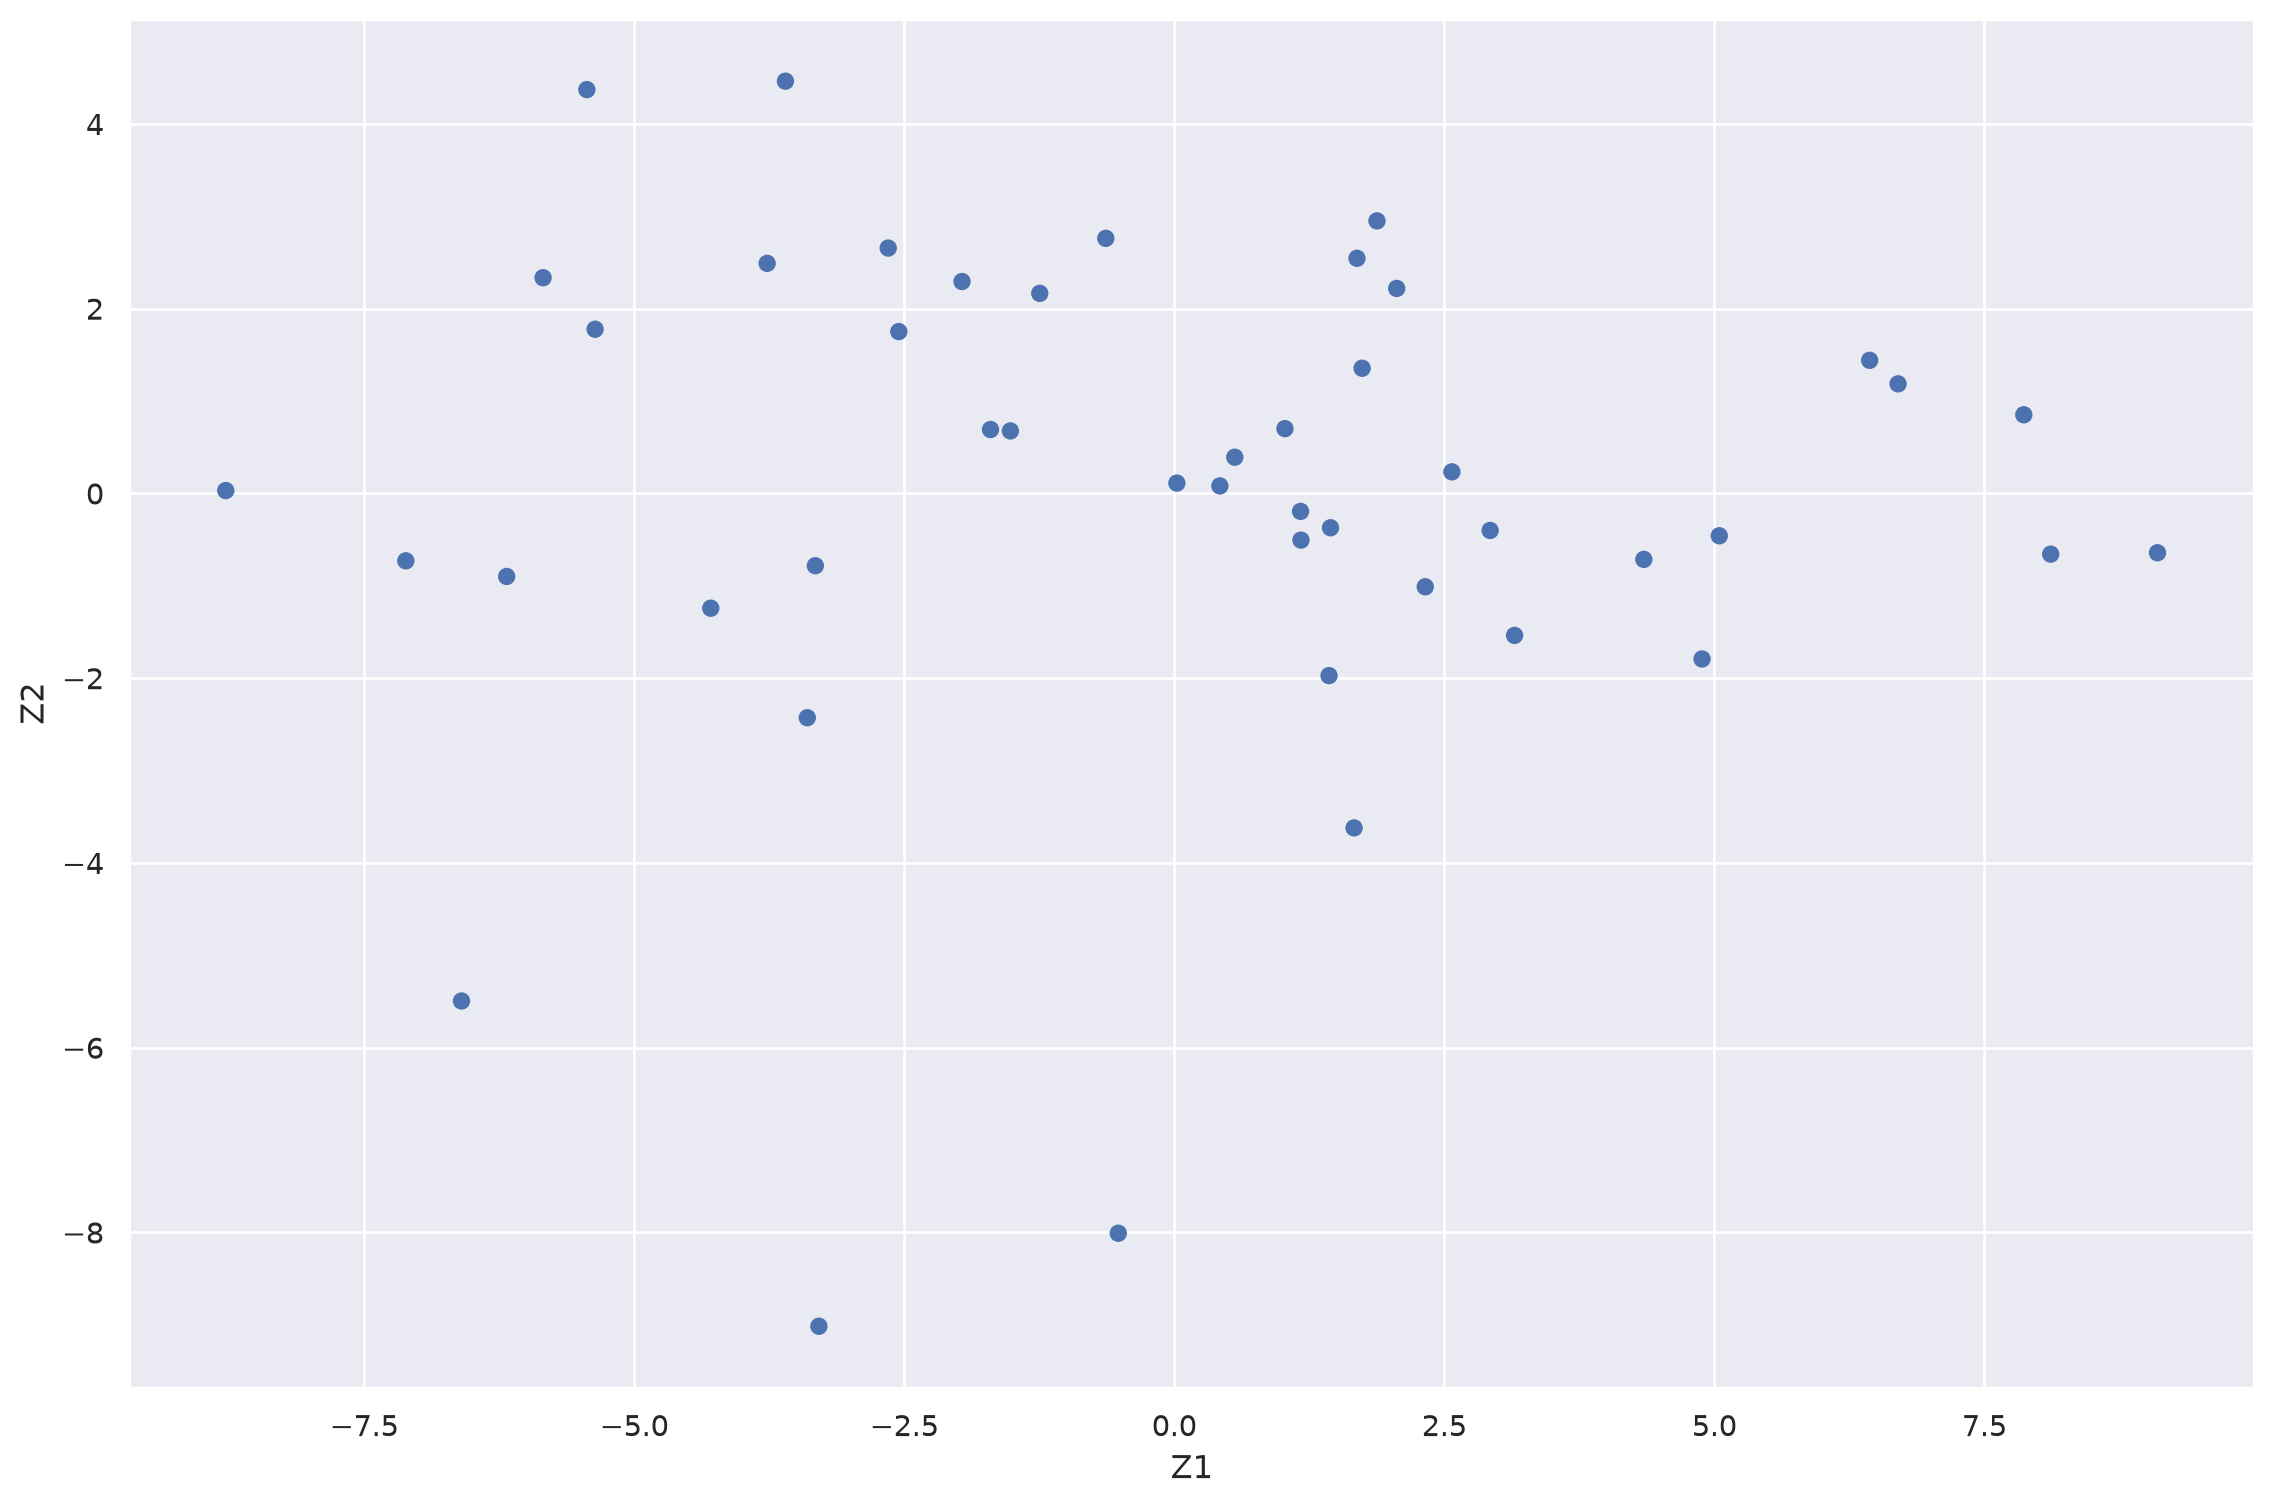

In [253]:
n_comps = 2
pca = PCA(n_components=n_comps)

X = df_selecciones_numerica_escalada
Z = pd.DataFrame(pca.fit_transform(X))

Z.columns = ["Z" + str(i) for i in range(1,n_comps+1)]  # Renombramos las columnas

# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2")
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Se puede ver que hay aproximadamente dos grupos, superior izquierda y superior derecha, con varios outliers en el inferior

## Ejercicio 2

In [254]:
z1 = pd.Series(pca.components_[0])
direcciones_z1 = pd.DataFrame({
	"valores_negativos": z1.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z1.sort_values().head(10).index],
	"valores_positivos": z1.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z1.sort_values(ascending=False).head(10).index]
})
direcciones_z1

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.014015,misc_performance_2crdy,0.224063,standard_performance_gpa
1,-0.009418,edad,0.218128,shooting_standard_sot
2,0.001081,misc_performance_crdr,0.214220,shooting_standard_sh
3,0.001081,standard_performance_crdr,0.212979,standard_performance_gls
4,0.016361,misc_performance_og,0.212842,shooting_standard_gls
5,0.031907,goles_seleccion,0.210781,standard_performance_g-pk
6,0.036041,caps,0.191854,standard_performance_ast
7,0.036422,shooting_standard_g_per_sh,0.190188,standard_playing_time_starts
8,0.083605,misc_performance_int,0.188728,standard_playing_time_90s
9,0.101740,misc_performance_crdy,0.188682,standard_playing_time_min


z1 le da principalmente peso a la cantidad de goles y asistencias, junto con la cantidad de tiempo/partidos jugados

In [255]:
z2 = pd.Series(pca.components_[1])
direcciones_z2 = pd.DataFrame({
	"valores_negativos": z2.sort_values().head(10).reset_index(drop=True),
	"columnas_negativas": [df_selecciones_numerica.columns[i] for i in z2.sort_values().head(10).index],
	"valores_positivos": z2.sort_values(ascending=False).head(10).reset_index(drop=True),
	"columnas_positivas": [df_selecciones_numerica.columns[i] for i in z2.sort_values(ascending=False).head(10).index]
})
direcciones_z2

,valores_negativos,columnas_negativas,valores_positivos,columnas_positivas
0,-0.284674,goles_seleccion,0.292684,misc_performance_int
1,-0.245326,caps,0.265067,misc_performance_tklw
2,-0.195709,standard_per_90_minutes_gls,0.262395,misc_performance_fls
3,-0.193217,standard_per_90_minutes_gpa,0.219218,standard_performance_crdy
4,-0.192035,standard_per_90_minutes_g-pk,0.217716,misc_performance_crdy
5,-0.191646,standard_per_90_minutes_gpa-pk,0.189744,misc_performance_fld
6,-0.147578,edad,0.170014,standard_playing_time_mp
7,-0.124537,standard_performance_pk,0.147201,standard_playing_time_min
8,-0.124537,shooting_standard_pk,0.147163,standard_playing_time_90s
9,-0.124453,standard_per_90_minutes_ast,0.146978,misc_performance_2crdy


z2 le da principalmente peso a otras características como tarjetas o intercepciones, y también a la cantidad de tiempo y partidos jugados

DAR INTERPRETACION!!!!!!!!!!!!!!!!!!

## Ejercicio 3

In [256]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

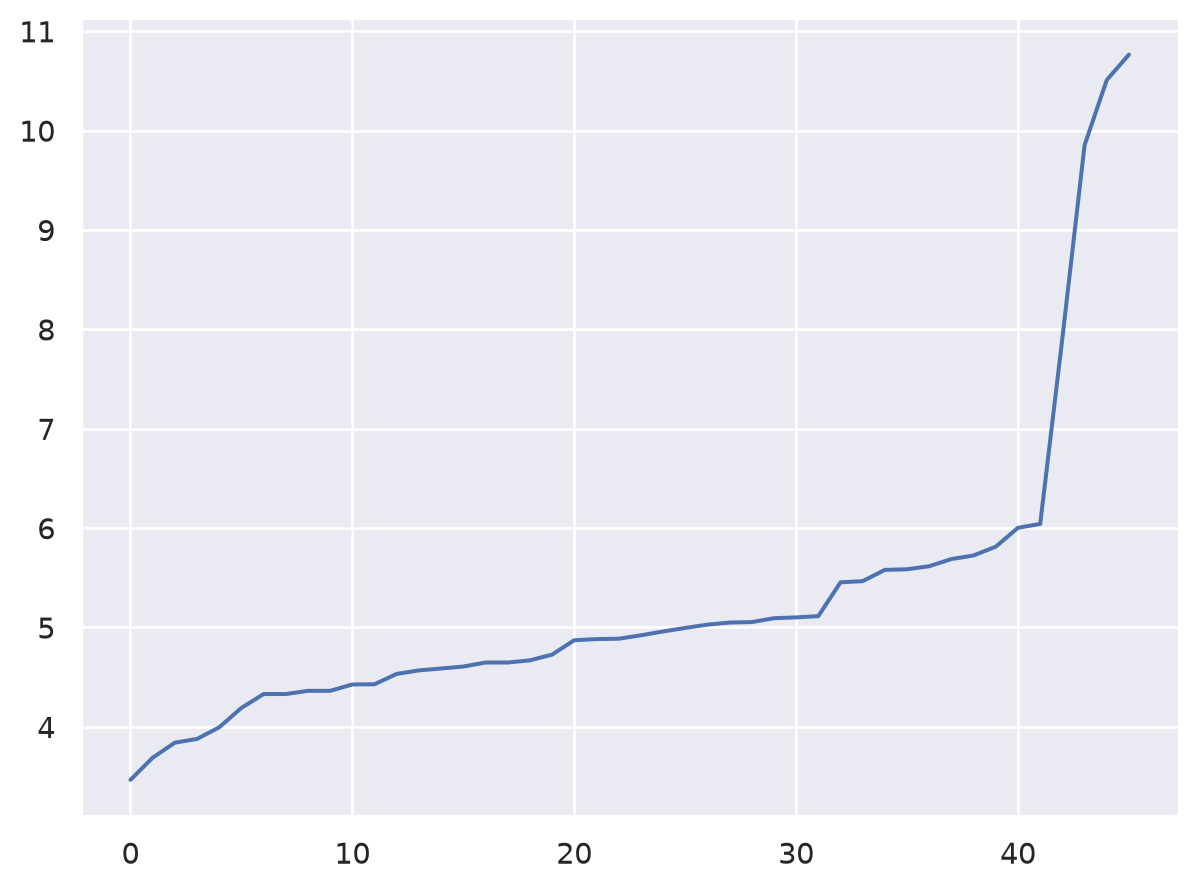

In [257]:
n_dbscan = 3
neighbors = NearestNeighbors(n_neighbors=n_dbscan)  # Esta función nos devuelve los más cercanos incluyendo a si mismo.
neighbors_fit = neighbors.fit(df_selecciones_numerica_escalada)

# Ordenamos de menor a mayor las distancias y graficamos
distances, indices = neighbors_fit.kneighbors(df_selecciones_numerica_escalada)
distances = distances[:,n_dbscan-1] # Tomamos la distancia al vecino más lejano (el n-ésimo vecino)
distances = np.sort(distances, axis=0)

so.Plot(x = np.arange(len(distances)), y = distances).add(so.Line())

In [258]:
clustering = DBSCAN(eps= 6, min_samples=n_dbscan)
etiqueta = clustering.fit_predict(df_selecciones_numerica_escalada)

In [259]:
kmeans = KMeans(4)
# Asignamos cada observación a un cluster
cluster = kmeans.fit_predict(df_selecciones_numerica_escalada)

## Ejercicio 4

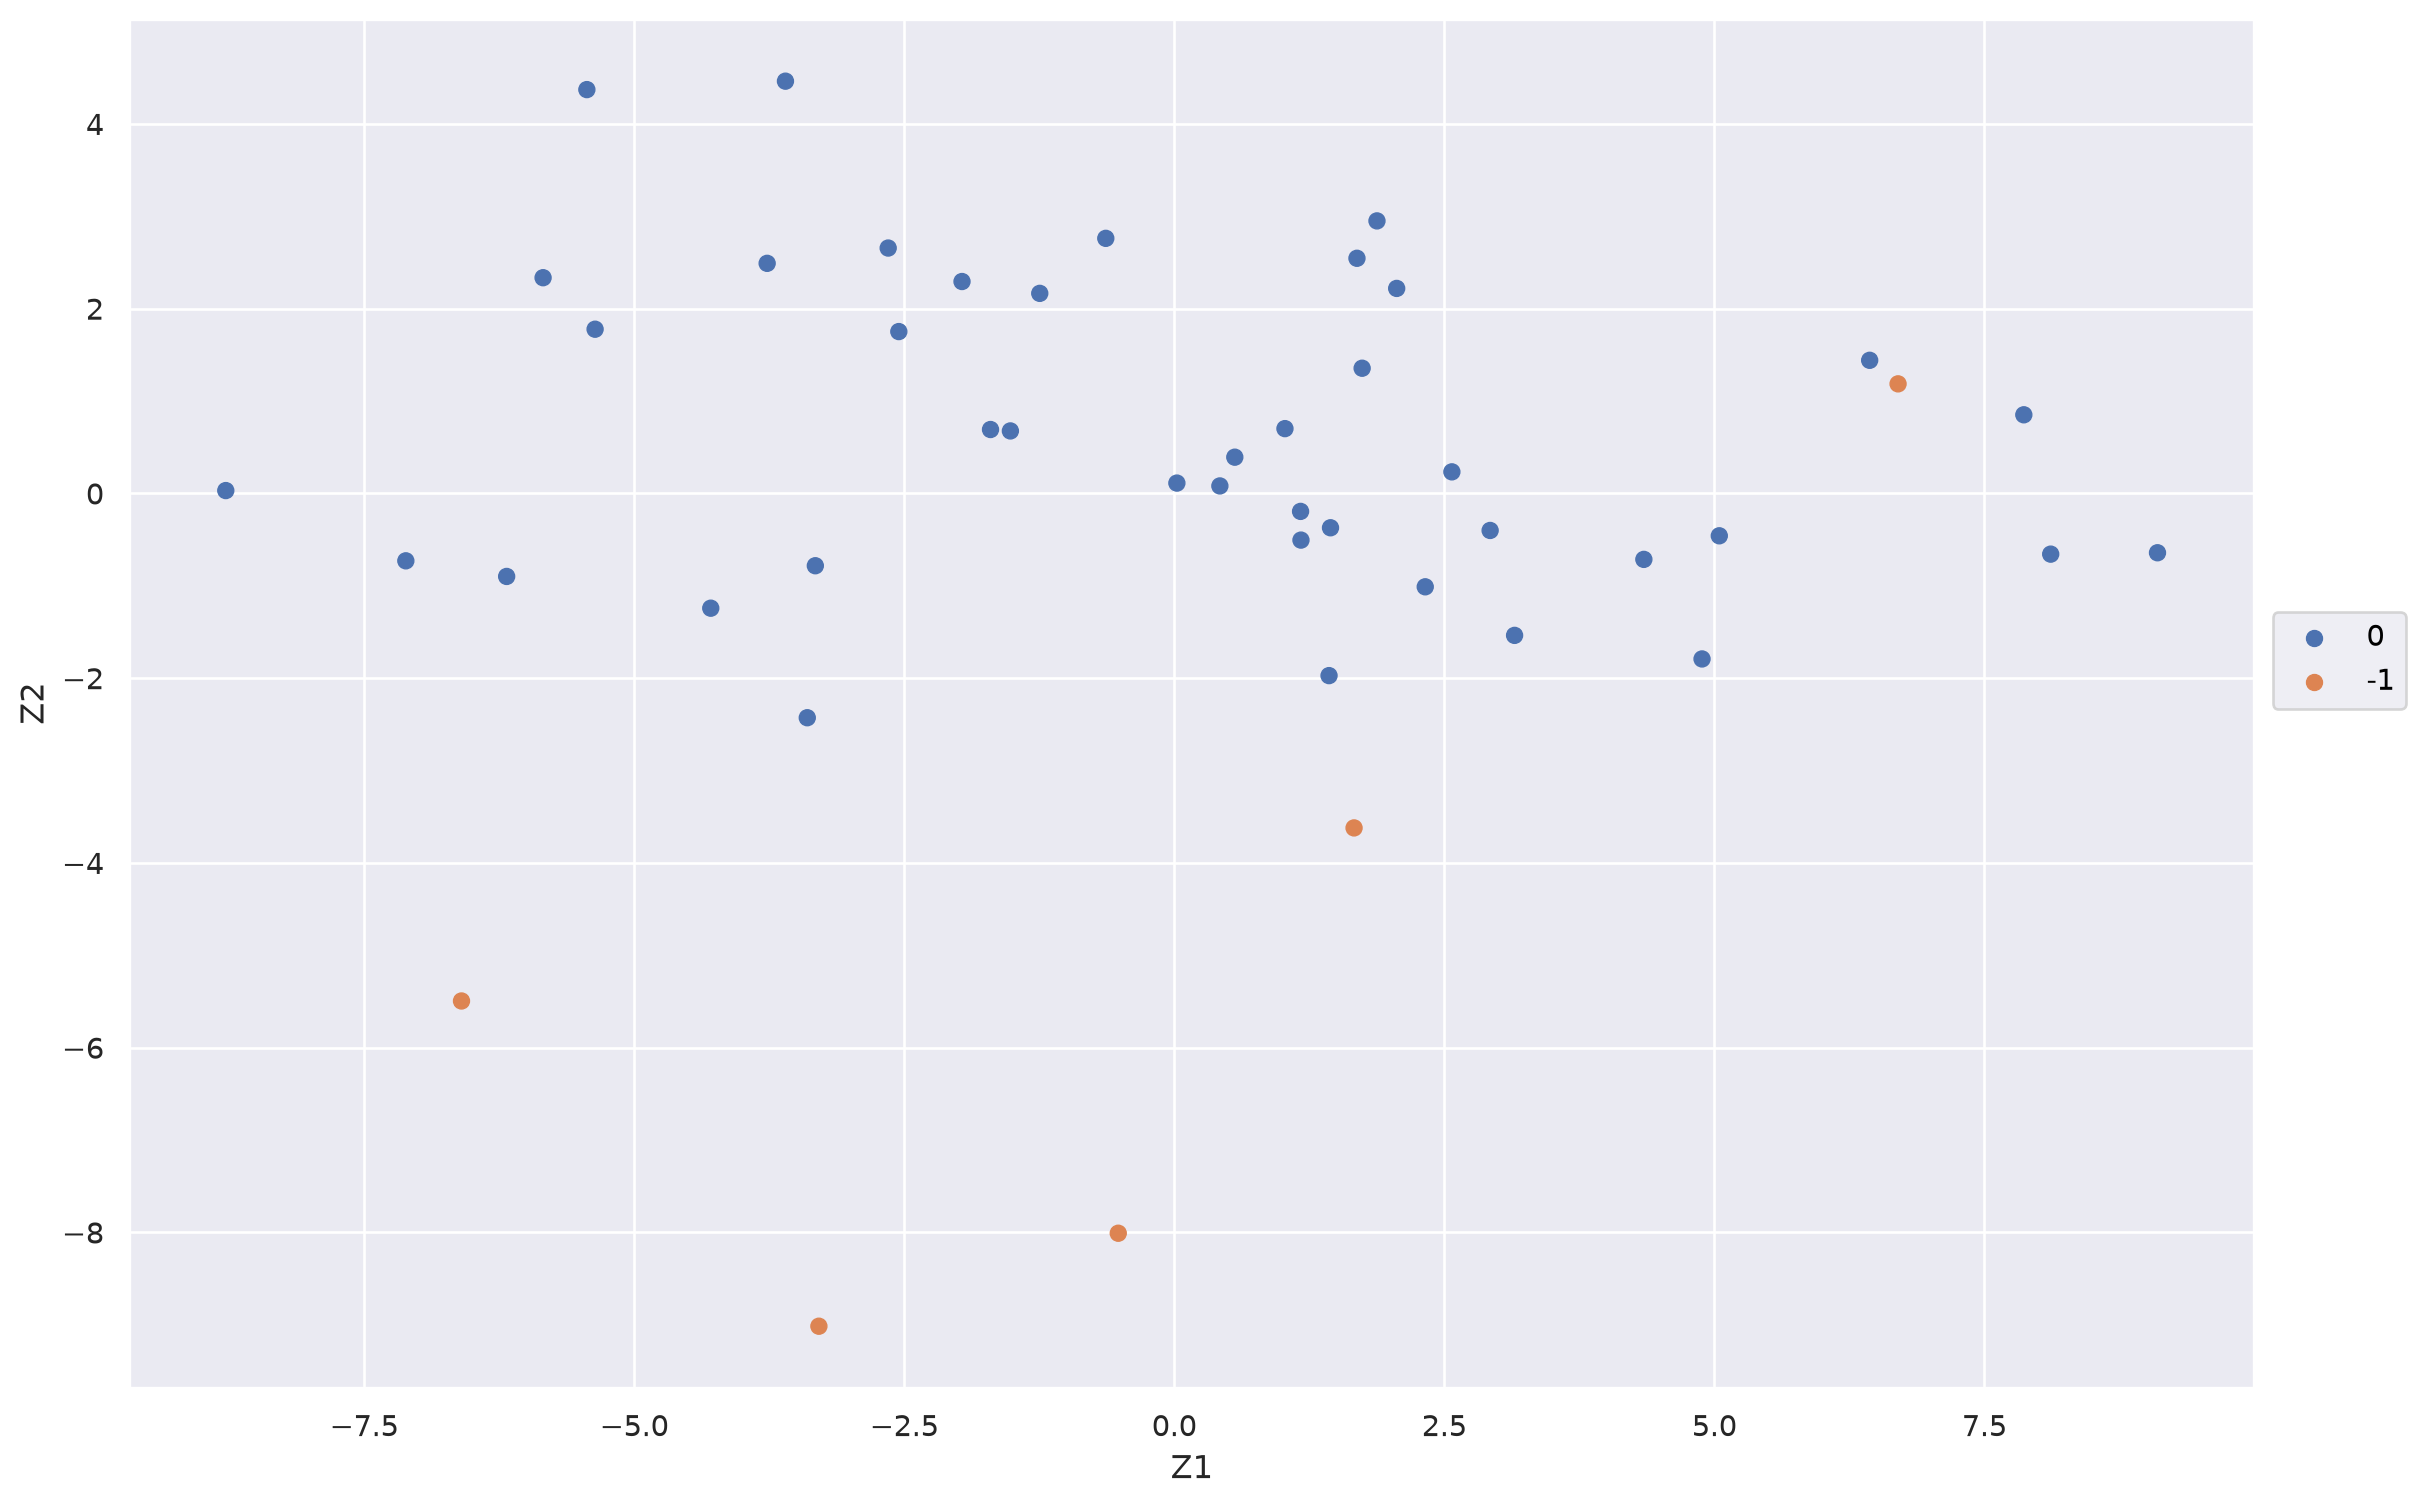

In [260]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", color = etiqueta.astype(str))
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

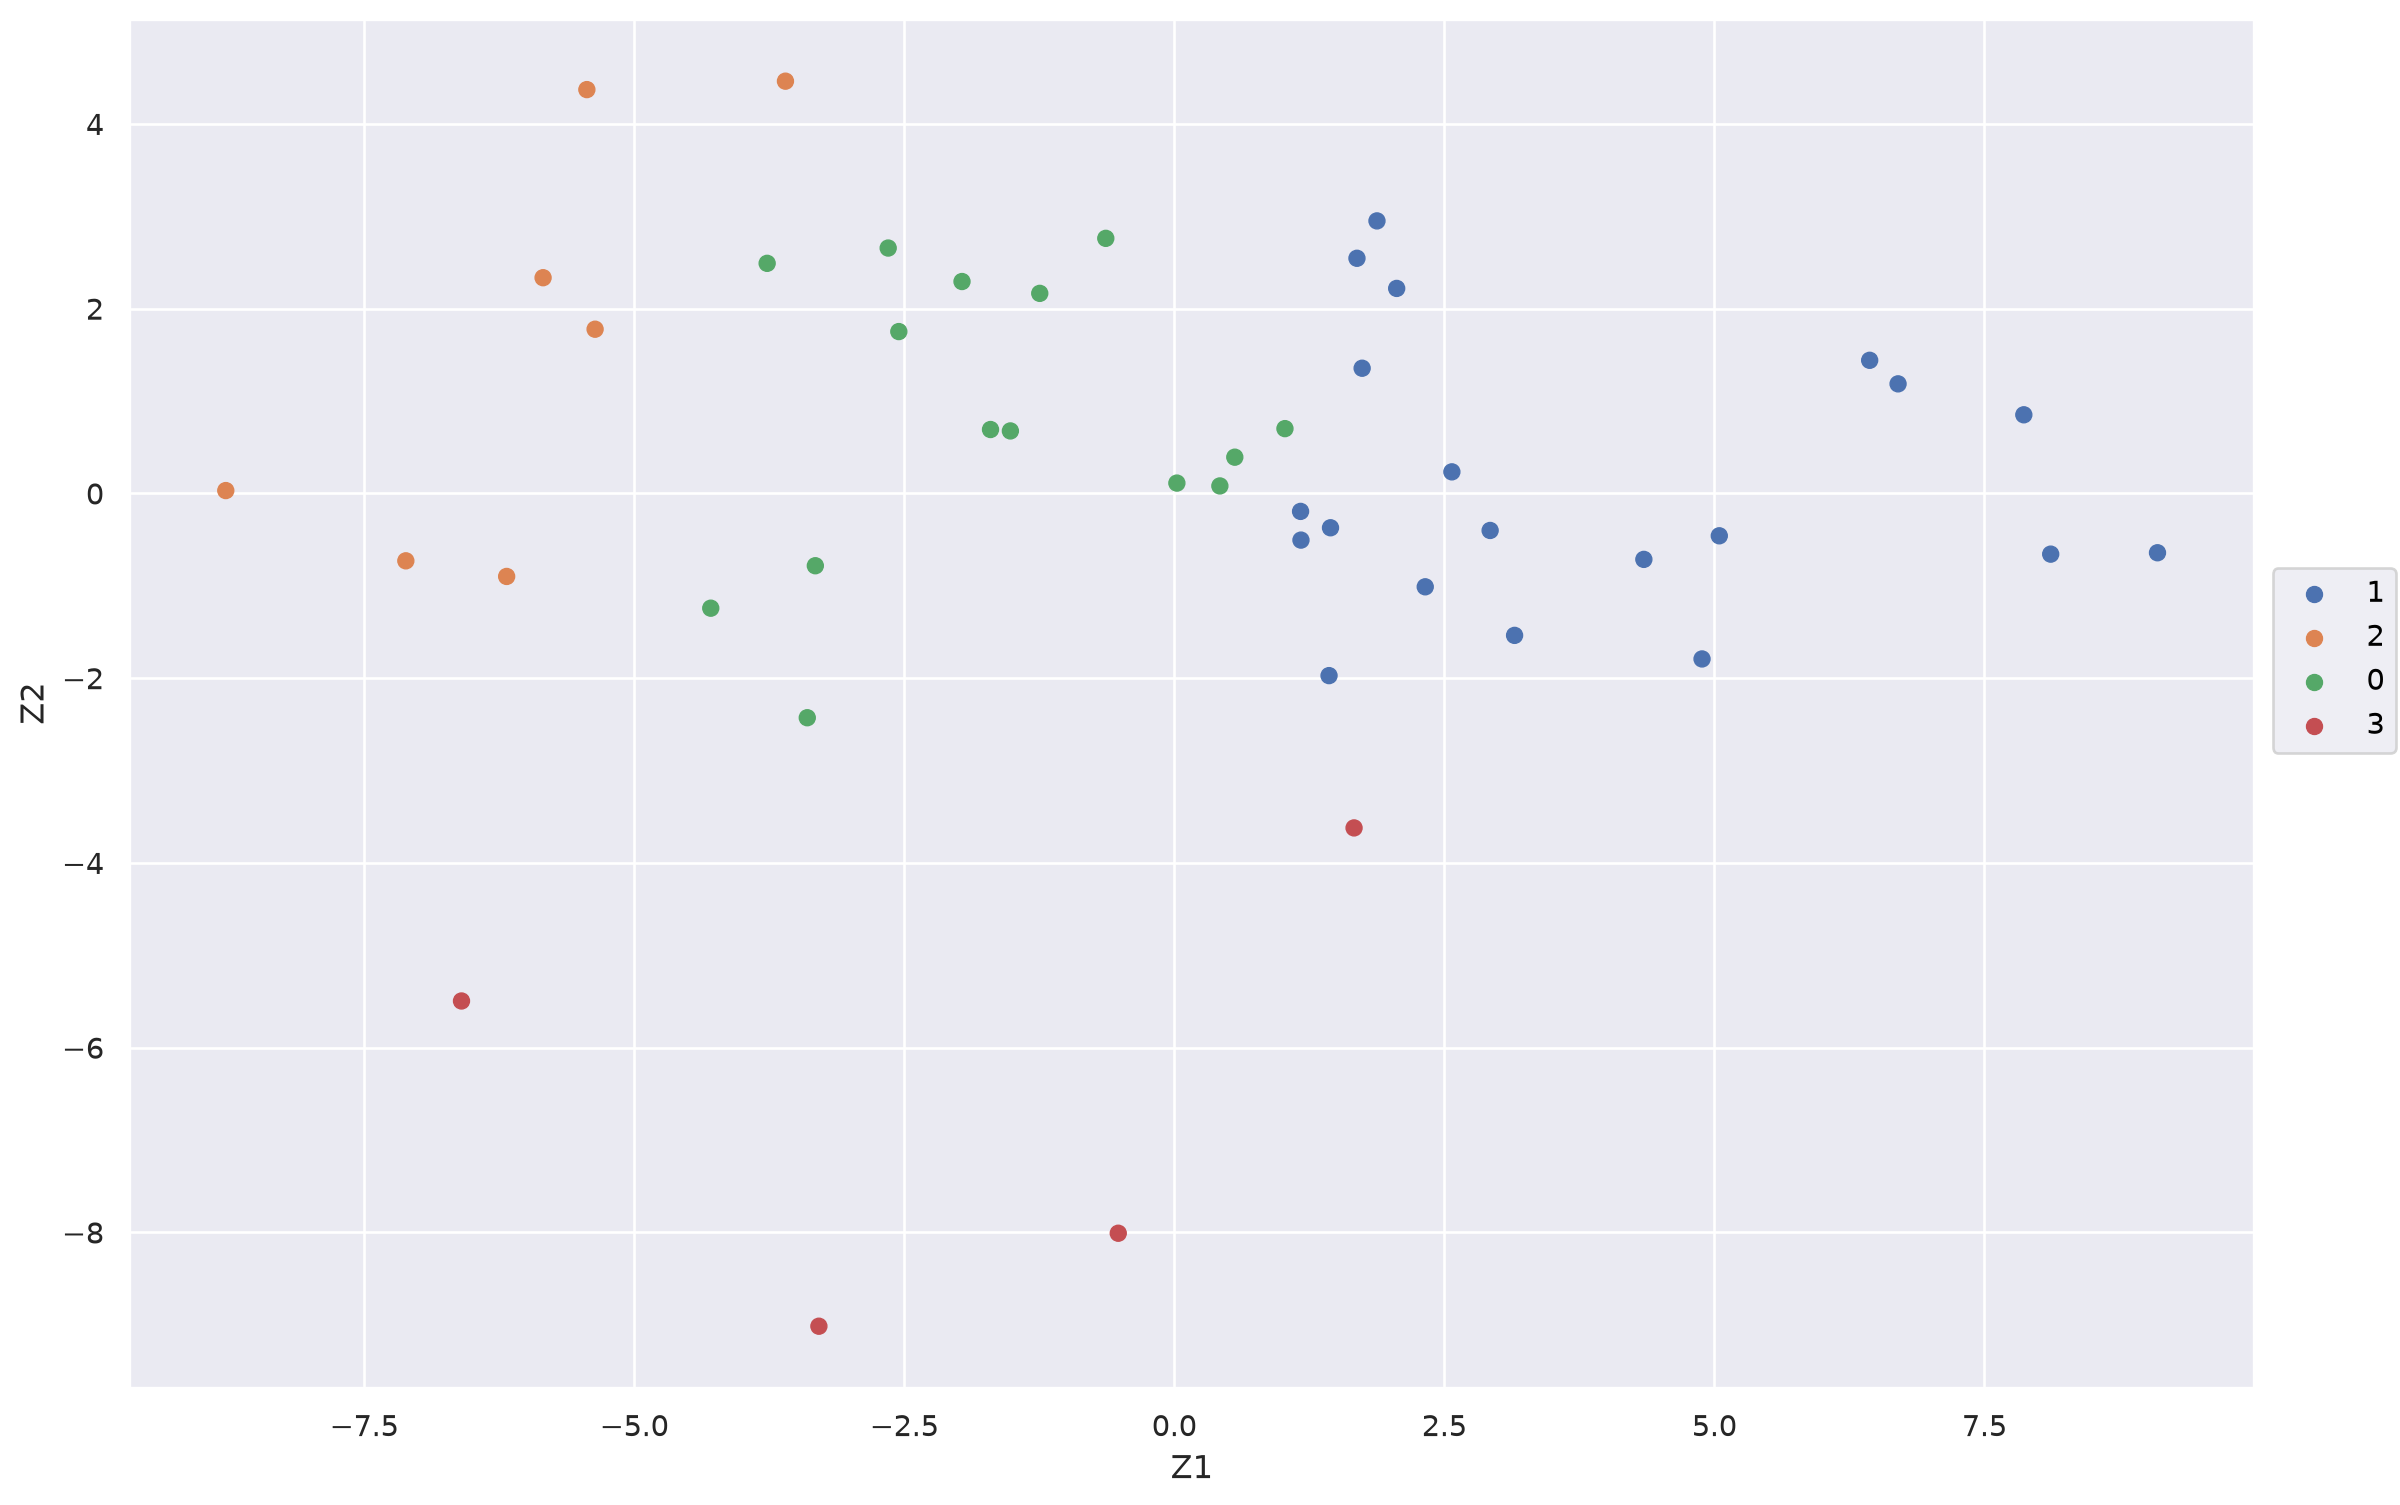

In [261]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", color = cluster.astype(str))
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

Una forma de verlo es que todas las selecciones tienen cantidad parecida de faltas/tarjetas (porque estan a misma altura en z2) pero aquellas que jugaron menos tiempo (negativo en z1) tienen peor rendimiento, pues generaron las mismas tarjetas y menos goles en menos tiempo de juego. Por ello los clusters se dividen de cierta forma segun el rendimiento "(tarjetas+goles)/(tiempo_jugado+partidos_jugados)".

Aunque parece que hay cierta coincidencia entre el clustering con los puntos creo que no es correcto, pues mete en un mismo cluster selecciones que varian mucho en z2 y entonces no comparten mismas características

In [262]:
X_star = df_selecciones_numerica_escalada

# Calculamos la matriz de covarianza:
# cov = (X - Xraya)^T * (X - Xraya) / N = (B^T * B) / N
X_star_t = np.transpose(X_star)
N = len(X_star)
Sigma = (X_star_t @ X_star) / N

gamma, U = np.linalg.eigh(Sigma)  # Calculamos los autovalores y autovectores de la matriz de covarianza

# Los autovalores están ordenados de menor a mayor.
# Damos vueltas las columnas de la matriz de autovectores usando np.flip(-,1)
gamma = np.flip(gamma)
U = np.flip(U, 1)

for i in range(n_comps):
    print("Variaza explicada por la componente ", i + 1, ": ", gamma[i] / sum(gamma))

print("Variaza acumulada: ", gamma[:n_comps].sum() / sum(gamma))

Variaza explicada por la componente  1 :  0.41767407936091516
Variaza explicada por la componente  2 :  0.16183109997172243
Variaza acumulada:  0.5795051793326376


Con las primeras dos componentes abarcamos la mitad de la varianza total, dando a entender que estamos perdiendo mucha información

## Ejercicio 5

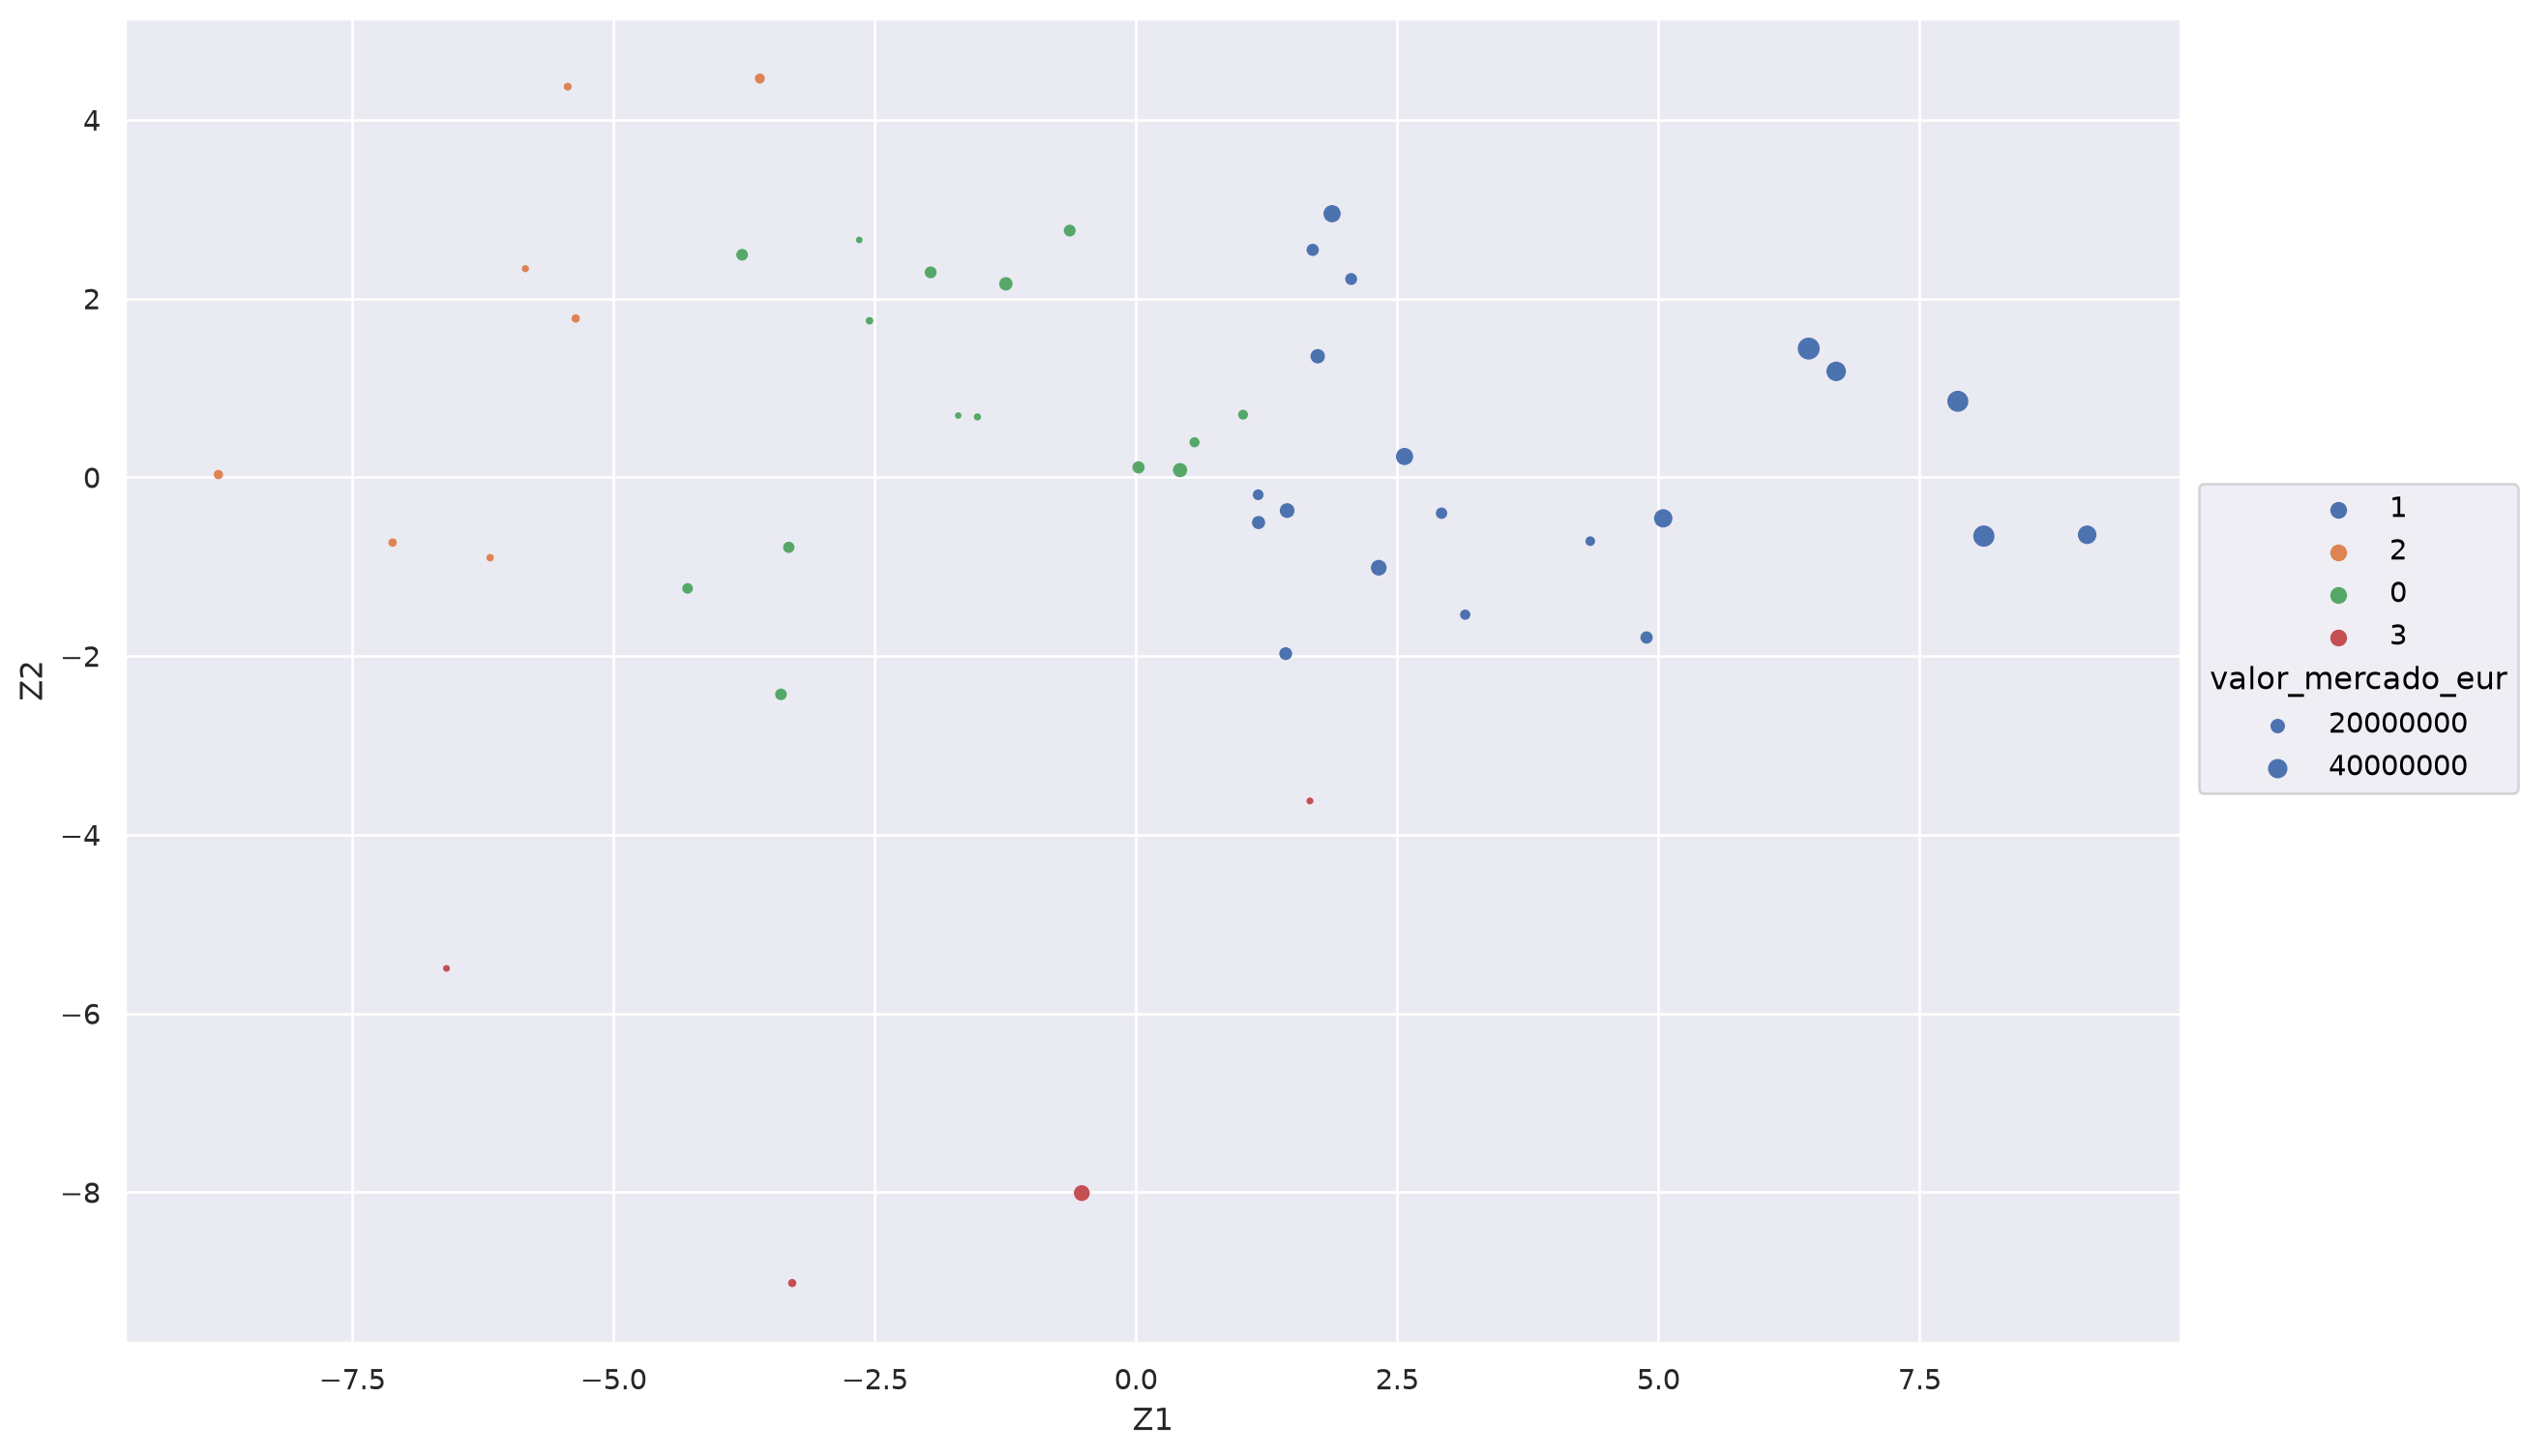

In [263]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", color = cluster.astype(str), pointsize=df_selecciones["valor_mercado_eur"])
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

# Regresión y clasificación

## Ejercicio 1

In [264]:
df_jugadores_regresion = df_jugadores_limpia.copy()
df_jugadores_regresion["partidos_liga"] = df_jugadores_regresion["standard_playing_time_min"] / 90
df_jugadores_regresion.head()

,player_id,seleccion,numero,posicion,jugador,fecha_nac,edad,caps,goles_seleccion,club,...,misc_performance_off,misc_performance_crs,misc_performance_int,misc_performance_tklw,misc_performance_og,nat3,valor_mercado_eur,posicion_tm,rango_etario,partidos_liga
0,1,Czech Republic,1,GK,Matěj Kovář,2000-05-17,26,19,0,PSV Eindhoven,...,0.0,0.0,1.0,0.0,0.0,CZE,7000000.0,Goalkeeper,B,31.000000
1,2,Czech Republic,2,DF,David Zima,2000-11-08,25,24,1,Slavia Prague,...,0.0,4.0,40.0,17.0,0.0,CZE,4500000.0,Centre-Back,B,20.633333
2,3,Czech Republic,3,DF,Tomáš Holeš,1993-03-31,33,40,2,Slavia Prague,...,1.0,22.0,44.0,24.0,0.0,CZE,2200000.0,Centre-Back,C,23.255556
3,4,Czech Republic,4,DF,Robin Hranáč,2000-01-29,26,13,1,TSG Hoffenheim,...,0.0,6.0,20.0,15.0,0.0,CZE,5500000.0,Centre-Back,B,25.011111
4,5,Czech Republic,5,DF,Vladimír Coufal,1992-08-22,33,61,2,TSG Hoffenheim,...,1.0,209.0,39.0,35.0,0.0,CZE,7000000.0,Right-Back,C,33.466667


In [265]:
# # Graficamos
# (
#     so.Plot(data = df_jugadores_regresion, x = "partidos_liga", y = "standard_playing_time_mp")
#     .add(so.Dot())
#     .add(so.Text())
#     .layout(size=(12,8))
# )

In [266]:
max_partidos = df_jugadores_regresion.groupby("confederacion")["standard_playing_time_mp"].max()
df_jugadores_regresion["partidos_liga"] = [jugador["standard_playing_time_min"]/(max_partidos[jugador["confederacion"]]*90) for _, jugador in df_jugadores_regresion.iterrows()]
# df_jugadores_regresion[["standard_playing_time_90s", "partidos_liga", "standard_playing_time_mp", "partidos_completos_porcentaje"]]
# max_partidos

## Ejercicio 2

In [267]:
from formulaic import Formula
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score

In [268]:
y = df_jugadores_regresion["partidos_liga"]
# X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero", "partidos_liga", "standard_playing_time_min"])
X = df_jugadores_regresion.select_dtypes(include='number').drop(columns=["player_id", "numero", "partidos_liga", "caps", "standard_playing_time_mp", "standard_playing_time_starts", "standard_playing_time_min", "standard_playing_time_90s", "shooting_90s", "misc_90s"])

In [269]:
test_split = 0.3 # probe con 0.1 y 0.2 y funciona sustancialmente mejor con 0.3
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [270]:
def evaluacion_modelo_final(modelo, X_train, y_train, X_test, y_test):
	# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento.
	modelo.fit(X_train, y_train)

	# Predicciones
	y_pred = modelo.predict(X_test)

	# Bondad del ajuste
	r2 = r2_score(y_test, y_pred)
	print('R^2: ', r2)
	recm = root_mean_squared_error(y_test, y_pred)
	print('Raiz cuadrada del ECM: ', recm)

In [271]:
modelo = LinearRegression(fit_intercept=True)    # Inicializamos un modelo de Regresion Lineal.

evaluacion_modelo_final(modelo, X_train, y_train, X_test, y_test)

R^2:  0.6025097333570828
Raiz cuadrada del ECM:  0.14217522454596115


In [283]:
alfas = [0, 0.1, 1, 1.2, 1.4, 1.6, 1.8, 2, 2.2, 2.4, 2.6, 2.8, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

rmse_train = {}  # Resulta útil guardar los valores en un diccionario
rmse_test = {}
intercept = {}
for alfa in alfas:
	splits = 5
	cv = KFold(n_splits=splits, random_state=random_state, shuffle=True)
	rmse2_train = np.zeros(cv.get_n_splits())
	rmse2_test = np.zeros(cv.get_n_splits())
	ind = 0
	ridge = Ridge(alpha=alfa)

	for train_index, val_index in cv.split(X_train):
		X_train2, X_val, y_train2, y_val = X_train.iloc[train_index], X_train.iloc[val_index], y_train.iloc[train_index], y_train.iloc[val_index]
		ridge.fit(X_train2, y_train2)
		rmse2_train[ind] = root_mean_squared_error(y_val, ridge.predict(X_val))
		rmse2_test[ind] = root_mean_squared_error(y_test, ridge.predict(X_test))
		ind += 1

	rmse_train[alfa] =  rmse2_train.mean()
	rmse_test[alfa] =  rmse2_test.mean()
	intercept[alfa] = ridge.intercept_

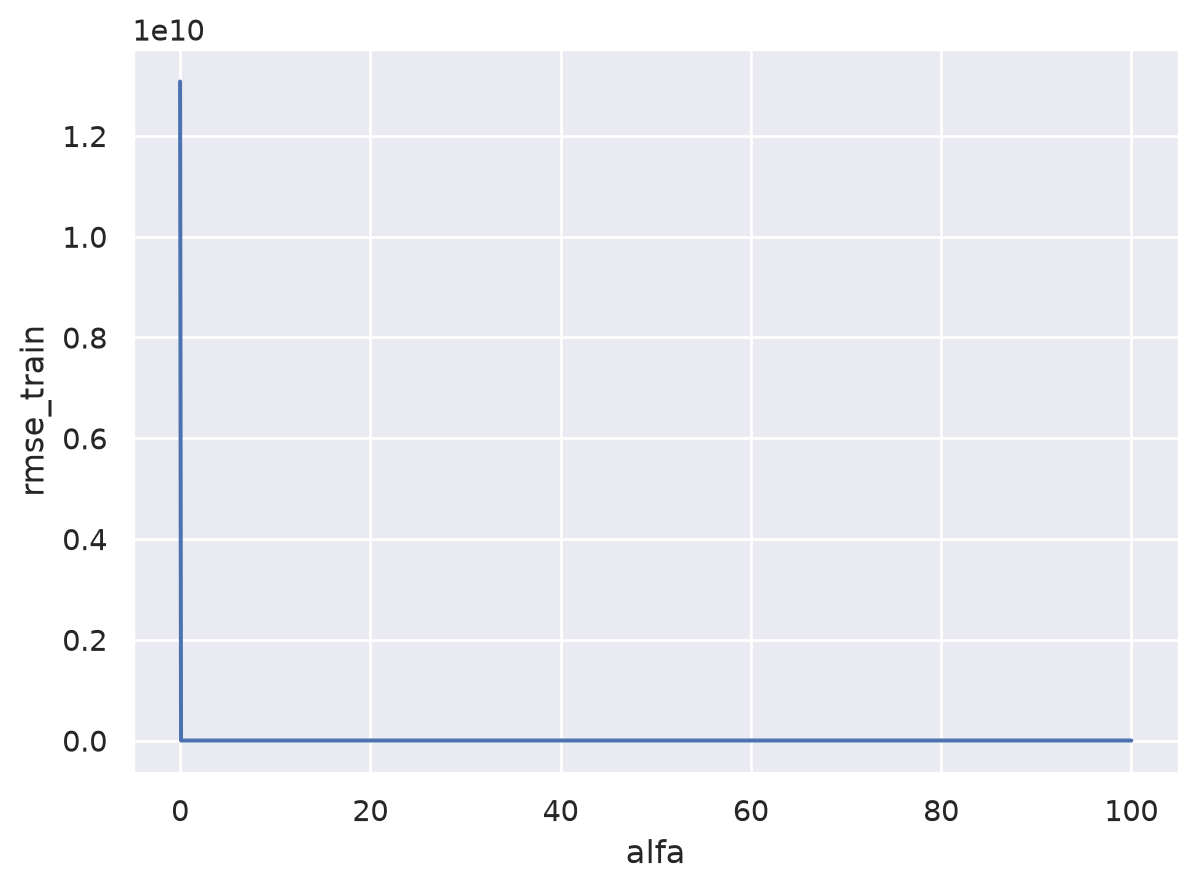

In [ ]:
# Convertimos a DataFrame para graficar
data = pd.DataFrame(
    {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "intercept": intercept,
    }
).reset_index(names="alfa")

# Graficamos los residuos en función de alfa
(
    so.Plot(data = data, x= "alfa")
    .add(so.Line(), y = "rmse_train")
    .add(so.Line(color = "red"), y = "rmse_test")
)

In [274]:
alpha = data["alfa"][(data["rmse_test"]+data["rmse_train"]).idxmin()]
print("El valor de alfa que minimiza el RMSE en test es: ", alpha)

ridge = Ridge(alpha=alpha)
evaluacion_modelo_final(ridge, X_train, y_train, X_test, y_test)
predicciones_tiempo = ridge.predict(X)

El valor de alfa que minimiza el RMSE en test es:  3.0
R^2:  0.5992801031374918
Raiz cuadrada del ECM:  0.1427516467980929


In [275]:
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": alfas}
gs = GridSearchCV(
    Ridge(),
    param_grid,
    cv=splits,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
)

evaluacion_modelo_final(gs, X_train, y_train, X_test, y_test)
print("alpha: " + str(gs.best_params_['alpha']))

R^2:  0.5992801031374918
Raiz cuadrada del ECM:  0.1427516467980929
alpha: 3


In [276]:
modelo = RidgeCV(
    alphas = alfas,
    cv = 5,
    scoring="neg_root_mean_squared_error")
evaluacion_modelo_final(modelo, X_train, y_train, X_test, y_test)
print("alpha: " + str(modelo.alpha_))

R^2:  0.5992801031374918
Raiz cuadrada del ECM:  0.1427516467980929
alpha: 3.0


Los modelos lineales Ridge funcionan mucho mejor que los multivariado

## Ejercicio 3

In [95]:
# Utilizamos NearestNeighbors para obtener los vecinos más cercanos
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
# Cargamos el comando mode
from statistics import mode
from sklearn.metrics import accuracy_score

In [96]:
# Juntamos todo en una función
def mas_votado(datos, categorias, ind, modelo):

    # Eliminamos al propio jugador, para no incluirlo en los vecinos.
    datos2 = datos.drop(index=ind)
    categorias2 = categorias.drop(index=ind)

    modelo.fit(datos2)

    distances, indices = modelo.kneighbors(datos.iloc[[ind]])
    votos = categorias2.iloc[indices.flatten()]

    # Los indices que devuelve kneighbors son posicion dentro del dataset (no indices del DF),
    # por eso tenemos que eliminar al jugador[ind] de las categorias

    return(mode(votos))

In [97]:
def knn_leave_one_out(datos, categorias, K):
    correctos = 0
    total = len(datos)
    # Tomamos K vecinos, porque eliminamos al propio jugador.
    neighbors = NearestNeighbors(n_neighbors=K)
    for ind in range(total):
        prediccion = mas_votado(datos, categorias, ind, neighbors)
        if(prediccion == categorias.iloc[ind]):
            correctos += 1
    return(correctos/total)

In [98]:
mapeo_posiciones = {
		"GK": 0,
		"DF": 1,
		"MF": 2,
		"FW": 3
}
# mapeo_posiciones_tm = {
# 	'Goalkeeper': 0,
# 	'Centre-Back': 1,
# 	'Right-Back': 2,
# 	'Central Midfield': 3,
# 	'Centre-Forward': 4,
# 	'Left-Back': 5,
# 	'Attacking Midfield': 6,
# 	'Left Winger': 7,
# 	'Right Midfield': 8,
# 	'Defensive Midfield': 9,
# 	'Right Winger': 10,
# 	'Left Midfield': 11,
# 	'Second Striker': 12
# }
# y = df_jugadores_limpia["posicion"].map(mapeo_posiciones)
y = df_jugadores_limpia["posicion"]
X = df_jugadores_limpia.select_dtypes(include='number').drop(columns=["player_id", "numero"])

In [99]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
aciertos = {}

for K in range(1,30,2):
	aciertos[K] = knn_leave_one_out(X_scaled, y, K)

aciertos = pd.DataFrame({
	"k": aciertos.keys(),
	"accuracy": aciertos.values()
})

In [100]:
ind_max = aciertos["accuracy"].idxmax()
k = aciertos["k"][ind_max]

print(f"El valor de k que maximiza los aciertos es: {k}, con {aciertos['accuracy'][ind_max]} porcentaje de precision")

# modelo_posiciones = KNeighborsClassifier(n_neighbors=k)
modelo_posiciones = NearestNeighbors(n_neighbors=k)
clasificacion_posiciones = []

for ind in range(len(X_scaled)):
	prediccion = mas_votado(X_scaled, y, ind, modelo_posiciones)
	clasificacion_posiciones.append(prediccion)

El valor de k que maximiza los aciertos es: 9, con 0.6934782608695652 porcentaje de precision


In [101]:
test_split = 0.1
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state)

In [102]:
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
data = {}
for K in range(1,30,2):
    neighbor = KNeighborsClassifier(n_neighbors=K)
    neighbor.fit(X_train_scaled,y_train)
    y_pred = neighbor.predict(X_test_scaled)
    data[K] = accuracy_score(y_test,y_pred)

data = pd.DataFrame({
    "k": data.keys(),
    "accuracy": data.values()
})

ind_max = data["accuracy"].idxmax()
k = data["k"][ind_max]
print(f"El valor de k que maximiza los aciertos es: {k}, con {data['accuracy'][ind_max]} porcentaje de precision")

knn_leave_one_out(X_scaled, y, k)

El valor de k que maximiza los aciertos es: 7, con 0.6521739130434783 porcentaje de precision


0.6608695652173913

Utilizando la variable posiciones_tm funciona considerablemente peor que utilizando posiciones

# El 11 ideal de Argentina y Brasil

In [104]:
df_jugadores_limpia["minutos_pred"] = predicciones_tiempo
df_jugadores_limpia["posicion_pred"] = clasificacion_posiciones

In [105]:
# Para armar el 11 ideal de cada pa´ıs, queremos seleccionar 1 arquero, 4 defensores, 4 mediocampistas y 2 atacantes entre los jugadores de cada pa´ıs. Vamos
# a utilizar las posiciones predichas en la secci´on anterior para determinar la posici´on de cada jugador y la variable minutos jugadores predicha para elegir en
# cada posicion al jugador con mas minutos.
# Armar el 11 de ideal de Argentina y Brasil siguiendo estas indicaciones.
# Considerar el 11 inicial del partido Argentina-Argelia y comparar esa selecci´on
# con la selecci´on armada por nuestro modelo.

mapeo_posiciones = {
		"GK": 0,
		"DF": 1,
		"MF": 2,
		"FW": 3
}

arquero_arg_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Argentina") & (df_jugadores_limpia["posicion_pred"] == "GK")]["minutos_pred"].idxmax()
arquero_arg = df_jugadores_limpia.loc[arquero_arg_ind]["jugador"]
arquero_bra_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Brazil") & (df_jugadores_limpia["posicion_pred"] == "GK")]["minutos_pred"].idxmax()
arquero_bra = df_jugadores_limpia.loc[arquero_bra_ind]["jugador"]

defensores_arg_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Argentina") & (df_jugadores_limpia["posicion_pred"] == "DF")]["minutos_pred"].sort_values(ascending=False).head(4).index
defensores_arg = df_jugadores_limpia.loc[defensores_arg_ind]["jugador"].tolist()
defensores_bra_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Brazil") & (df_jugadores_limpia["posicion_pred"] == "DF")]["minutos_pred"].sort_values(ascending=False).head(4).index
defensores_bra = df_jugadores_limpia.loc[defensores_bra_ind]["jugador"].tolist()

mediocampistas_arg_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Argentina") & (df_jugadores_limpia["posicion_pred"] == "MF")]["minutos_pred"].sort_values(ascending=False).head(4).index
mediocampistas_arg = df_jugadores_limpia.loc[mediocampistas_arg_ind]["jugador"].tolist()
mediocampistas_bra_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Brazil") & (df_jugadores_limpia["posicion_pred"] == "MF")]["minutos_pred"].sort_values(ascending=False).head(4).index
mediocampistas_bra = df_jugadores_limpia.loc[mediocampistas_bra_ind]["jugador"].tolist()

delanteros_arg_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Argentina") & (df_jugadores_limpia["posicion_pred"] == "FW")]["minutos_pred"].sort_values(ascending=False).head(2).index
delanteros_arg = df_jugadores_limpia.loc[delanteros_arg_ind]["jugador"].tolist()
delanteros_bra_ind = df_jugadores_limpia[(df_jugadores_limpia["seleccion"] == "Brazil") & (df_jugadores_limpia["posicion_pred"] == "FW")]["minutos_pred"].sort_values(ascending=False).head(2).index
delanteros_bra = df_jugadores_limpia.loc[delanteros_bra_ind]["jugador"].tolist()

In [106]:
titulares = [
	"Emiliano Martínez", # Arquero

	# Defensores
	"Cristian Romero",
	"Facundo Medina",
	"Gonzalo Montiel",
	"Lisandro Martínez",

	# Mediocampistas
	"Alexis Mac Allister",
	"Enzo Fernández",
	"Rodrigo De Paul",
	"Thiago Almada",

	# Delanteros
	"Lautaro Martínez",
	"Lionel Messi"
]

defensores_arg.sort()
mediocampistas_arg.sort()
delanteros_arg.sort()

once_arg = pd.DataFrame({
	"Posición": ["Arquero"] + ["Defensor"]*4 + ["Mediocampista"]*4 + ["Delantero"]*2,
	"Jugador": [arquero_arg] + defensores_arg + mediocampistas_arg + delanteros_arg,
	"vs Argelia": titulares
})
once_arg

,Posición,Jugador,vs Argelia
0,Arquero,Emiliano Martínez,Emiliano Martínez
1,Defensor,Alexis Mac Allister,Cristian Romero
2,Defensor,Cristian Romero,Facundo Medina
3,Defensor,Leonardo Balerdi,Gonzalo Montiel
4,Defensor,Nicolás Otamendi,Lisandro Martínez
5,Mediocampista,Enzo Fernández,Alexis Mac Allister
6,Mediocampista,Giovani Lo Celso,Enzo Fernández
7,Mediocampista,Giuliano Simeone,Rodrigo De Paul
8,Mediocampista,Nicolás Tagliafico,Thiago Almada
9,Delantero,Lautaro Martínez,Lautaro Martínez


In [107]:
titulares = [
    "Alisson",  # Arquero

    # Defensores
    "Douglas Santos",
    "Gabriel Magalhães",
    "Ibañez",
    "Marquinhos",

    # Mediocampistas
    "Bruno Guimarães",
    "Casemiro",

    # Delanteros
    "Lucas Paquetá",
    "Raphinha",
    "Thiago",
    "Vinícius Júnior"
]

defensores_bra.sort()
mediocampistas_bra.sort()
delanteros_bra.sort()

once_bra = pd.DataFrame({
	"Posición": ["Arquero"] + ["Defensor"]*4 + ["Mediocampista"]*4 + ["Delantero"]*2,
	"Jugador": [arquero_bra] + defensores_bra + mediocampistas_bra + delanteros_bra,
	"vs Marruecos": titulares
})
once_bra

,Posición,Jugador,vs Marruecos
0,Arquero,Weverton,Alisson
1,Defensor,Fabinho,Douglas Santos
2,Defensor,Léo Pereira,Gabriel Magalhães
3,Defensor,Roger Ibañez,Ibañez
4,Defensor,Wesley,Marquinhos
5,Mediocampista,Bruno Guimarães,Bruno Guimarães
6,Mediocampista,Casemiro,Casemiro
7,Mediocampista,Gabriel Magalhães,Lucas Paquetá
8,Mediocampista,Matheus Cunha,Raphinha
9,Delantero,Igor Thiago,Thiago
